#### Dependencies

In [ ]:
print('debug')

debug


In [ ]:
# ============================================================
# Standard library
# ============================================================
import gc
import json
import sys
import warnings
import os 
from pathlib import Path
from typing import Dict, Generator, List, Tuple

# ============================================================
# Third-party libraries
# ============================================================
import lightgbm as lgb
import numpy as np
import pandas as pd
import pyarrow as pa
import xgboost as xgb
from pandas.api.types import CategoricalDtype
from scipy.stats import poisson, spearmanr
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import TimeSeriesSplit
import optuna 
from optuna.importance import get_param_importances
import matplotlib.pyplot as plt
# ============================================================
# Configuration
# ============================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ============================================================
# Project paths
# ============================================================
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CONFIG_PATH = PROJECT_ROOT / "configs" / "1x2"
# ============================================================
# Project modules
# ============================================================

from src.utils.utils import (
      split_data,
      clean_key_missing,
      prepare_data_for_training,
      align_frame_to_reference,
      assert_same_categorical_schema,
      categorical_columns,
  )

from src.preprocessing.preprocessing import (
    preprocessing_1x2_extra_time_filter,
    clean_dataset,
)

from src.metrics.metrics import (
    calculate_rps,
    log_loss,
    calculate_ece,
    evaluate_model,
)

from src.evaluation.evaluation import (
    calculate_rps_single,
    get_vectorized_rps,
)

from src.training.training import (
    train_and_evaluate_lgbm,
    timeseries_cv_evaluate,
    apply_target_encoding_to_validation,
    run_logistic_cv,
    train_and_evaluate_hardcoded,
)

from src.feature_selection.feature_selection import (
    PipelineConfig,
    PipelineReport,
    run_feature_selection_pipeline,
    diagnose_schema,
    reanalyze_significance,
    walk_forward_selection_stability,
)

from src.hypertunning.hypertunning import (
    load_optuna_spaces,
    create_optuna_study,
    create_optuna_objective,
    _sanitize_params,
    export_optuna_tuning_results,
)

from src.error_analysis.error_analysis import SoccerModelErrorAnalyzer
# ============================================================
# Experiment configuration
# ============================================================
TRAIN_MODE = True

COMP_TYPE = "clubs"

DATA_PATH = DATA_DIR / COMP_TYPE
RANDOM_STATE = 67
FEATURE_SELECTION_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset"
METRICS_DIR = OUTPUTS_DIR / COMP_TYPE / "model_metrics"
MODELS_DIR = OUTPUTS_DIR / COMP_TYPE / "models" / "1x2" 

SPLITS = {
    "train": ["2021/2022", "2022/2023", "2023/2024"],
    "val": ["2024/2025"],
    "test": ["2025/2026"],
}

# ============================================================
# Load data
# ============================================================
gc.collect()

df = pd.read_parquet(DATA_PATH / "club_features_full.parquet")

df.head()

c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


match_id        match_datetime_utc season_id  home_team_id  away_team_id  \
0  12437642 2024-08-23 19:30:00+00:00     61643          2833          2819   
1  12437643 2025-01-24 20:00:00+00:00     61643          6577          2820   
2  12437647 2024-08-25 17:00:00+00:00     61643          2845          6577   
3  12437652 2024-08-24 17:00:00+00:00     61643          2817          2825   
4  12437656 2024-08-24 15:00:00+00:00     61643          2820          2826   

   home_score  away_score  home_venue_id  home_referee_id  \
0         1.0         2.0           86.0         351144.0   
1         1.0         1.0           88.0          86508.0   
2         2.0         1.0          102.0          92296.0   
3         2.0         1.0           80.0          86508.0   
4         1.0         0.0           93.0         137895.0   

   home_macro_rolling_goals  home_macro_rolling_fouls  \
0                      3.36                     25.50   
1                      3.12                     22.70   
2                      2.80                     23.88   
3                      3.10                     24.18   
4                      3.18                     24.88   

   home_macro_rolling_yellows  home_team_avg_goals_last_5  \
0                        4.40                         1.0   
1                        4.22                         0.6   
2                        4.24                         1.0   
3                        4.06                         2.2   
4                        4.10                         1.8   

   home_team_avg_xg_last_5  home_team_avg_buildup_last_5  \
0                    1.446                          87.8   
1                    1.105                         110.8   
2                    0.980                          62.0   
3                    1.910                         135.0   
4                    1.194                         105.4   

   home_team_avg_conceded_last_5  home_team_clean_sheet_pct_last_5  \
0                            2.0                               0.0   
1                            2.0                               0.4   
2                            1.0                               0.4   
3                            0.4                               0.6   
4                            1.2                               0.0   

   home_team_avg_xga_last_5  home_team_avg_ppda_last_5  \
0                     2.034                  10.634066   
1                     2.230                  10.030864   
2                     1.740                  10.492063   
3                     1.070                  10.006186   
4                     1.296                  11.057341   

   home_team_avg_yellows_last_5  home_opponent_avg_yellows_last_5  \
0                           3.2                               1.8   
1                           2.2                               2.4   
2                           3.5                               1.5   
3                           2.2                               1.8   
4                           2.6                               2.0   

   home_team_avg_reds_last_5  home_opponent_avg_reds_last_5  \
0                        0.0                            0.0   
1                        0.2                            0.0   
2                        0.0                            0.0   
3                        0.0                            0.0   
4                        0.0                            0.0   

   home_team_avg_cards_per_foul_last_5  home_team_avg_fouls_committed_last_5  \
0                             0.244048                                  11.6   
1                             0.181392                                  12.2   
2                             0.223982                                  14.0   
3                             0.183020                                  11.0   
4                             0.190476                                  12.4   

   home_team_avg_fouls_drawn_last_5  home_tea

In [3]:
df = pd.read_parquet(DATA_PATH / "club_features_full.parquet")
df.head()

match_id        match_datetime_utc season_id  home_team_id  away_team_id  \
0  12437642 2024-08-23 19:30:00+00:00     61643          2833          2819   
1  12437643 2025-01-24 20:00:00+00:00     61643          6577          2820   
2  12437647 2024-08-25 17:00:00+00:00     61643          2845          6577   
3  12437652 2024-08-24 17:00:00+00:00     61643          2817          2825   
4  12437656 2024-08-24 15:00:00+00:00     61643          2820          2826   

   home_score  away_score  home_venue_id  home_referee_id  \
0         1.0         2.0           86.0         351144.0   
1         1.0         1.0           88.0          86508.0   
2         2.0         1.0          102.0          92296.0   
3         2.0         1.0           80.0          86508.0   
4         1.0         0.0           93.0         137895.0   

   home_macro_rolling_goals  home_macro_rolling_fouls  \
0                      3.36                     25.50   
1                      3.12                     22.70   
2                      2.80                     23.88   
3                      3.10                     24.18   
4                      3.18                     24.88   

   home_macro_rolling_yellows  home_team_avg_goals_last_5  \
0                        4.40                         1.0   
1                        4.22                         0.6   
2                        4.24                         1.0   
3                        4.06                         2.2   
4                        4.10                         1.8   

   home_team_avg_xg_last_5  home_team_avg_buildup_last_5  \
0                    1.446                          87.8   
1                    1.105                         110.8   
2                    0.980                          62.0   
3                    1.910                         135.0   
4                    1.194                         105.4   

   home_team_avg_conceded_last_5  home_team_clean_sheet_pct_last_5  \
0                            2.0                               0.0   
1                            2.0                               0.4   
2                            1.0                               0.4   
3                            0.4                               0.6   
4                            1.2                               0.0   

   home_team_avg_xga_last_5  home_team_avg_ppda_last_5  \
0                     2.034                  10.634066   
1                     2.230                  10.030864   
2                     1.740                  10.492063   
3                     1.070                  10.006186   
4                     1.296                  11.057341   

   home_team_avg_yellows_last_5  home_opponent_avg_yellows_last_5  \
0                           3.2                               1.8   
1                           2.2                               2.4   
2                           3.5                               1.5   
3                           2.2                               1.8   
4                           2.6                               2.0   

   home_team_avg_reds_last_5  home_opponent_avg_reds_last_5  \
0                        0.0                            0.0   
1                        0.2                            0.0   
2                        0.0                            0.0   
3                        0.0                            0.0   
4                        0.0                            0.0   

   home_team_avg_cards_per_foul_last_5  home_team_avg_fouls_committed_last_5  \
0                             0.244048                                  11.6   
1                             0.181392                                  12.2   
2                             0.223982                                  14.0   
3                             0.183020                                  11.0   
4                             0.190476                                  12.4   

   home_team_avg_fouls_drawn_last_5  home_tea

In [4]:
df_prepared = preprocessing_1x2_extra_time_filter(df, DATA_PATH)

The Number of matches eliminated on this filter is: 93 & Total: 14069


In [5]:
EXCLUDE_COLS, LEAKY_COLS, TARGET_COL = clean_dataset(df_prepared)

In [6]:
exclude_list = ["match_datetime_utc", "name", "match_id", "tournament"]

TARGET_COL = "target_result"

df_cleaned = clean_key_missing(df_prepared, cols_to_check = ["home_score", "away_score"])

df_train, df_val, df_test = split_data(
    df,
    SPLITS
)

print(f"The shape of the TRAIN DATA IS: {df_train.shape}")
print(f"The shape of the VAL DATA IS: {df_val.shape}")
print(f"The shape of the TEST DATA IS: {df_test.shape}")


X_train, y_train = prepare_data_for_training(df_train, EXCLUDE_COLS, LEAKY_COLS, TARGET_COL)

X_val, y_val = prepare_data_for_training(df_val, EXCLUDE_COLS, LEAKY_COLS, TARGET_COL)

X_test, y_test = prepare_data_for_training(df_test, EXCLUDE_COLS, LEAKY_COLS, TARGET_COL)

print(f"The TRAIN SHAPE IS: {X_train.shape} & {y_train.shape}")
print(f"The VAL SHAPE IS: {X_val.shape} & {y_val.shape}")
print(f"The TEST SHAPE IS: {X_test.shape} & {y_test.shape}")


Removed 1755 rows with missing key odds.
Remaining rows: 12314
The shape of the TRAIN DATA IS: (7442, 1410)
The shape of the VAL DATA IS: (2369, 1410)
The shape of the TEST DATA IS: (2599, 1410)
The TRAIN SHAPE IS: (7442, 1050) & (7442,)
The VAL SHAPE IS: (2369, 1050) & (2369,)
The TEST SHAPE IS: (2599, 1050) & (2599,)


### Baseline

In [11]:
# ================================================================================
#  TEMPORAL FEATURE SELECTION PIPELINE
#  Implementacion: src/feature_selection/feature_selection.py
#  Valores del experimento: configs/1x2/feature_selection_pipeline.py
#  Requiere en memoria: X_train, X_val, X_test, y_train, y_val
# ================================================================================
CONFIG: PipelineConfig = PipelineConfig(
    auto_detect_string_categoricals=True,
    corr_n_blocks=5,
    corr_threshold=0.75,

    # Categoricas: declararlas a mano si hay IDs/codigos numericos
    explicit_categorical=None,

    mi_threshold=1e-4,

    parametric_dist="lognormal",
    preflight_abort=False,

    random_state=RANDOM_STATE,

    require_empirical_floor=True,

    # STEP 4
    run_stability_filter=True,

    # STEP 5 - no desactivar
    run_validation=True,

    # STEP 3 - 100 runs con permutacion por bloques > 200 runs i.i.d. mal especificadas
    shuffle_block_size=0,         # 0 = auto desde la persistencia del target
    shuffle_boost_rounds=100,
    shuffle_fdr_alpha=0.05,
    shuffle_n_runs=100,
    shuffle_n_strata=10,
    shuffle_sample_size=1500,
    shuffle_use_two_pass=False,

    significance_method="zscore",    # "parametric_bh" para el criterio formal

    # STEP 0 - 0.98 en vez de 0.75: con ~7.4k filas, 0.75 tira features raras utiles
    sparsity_threshold=0.98,

    stability_min_score=0.35,
    stability_n_windows=5,
    stability_penalty_k=1.0,

    strict_schema_alignment=True,

    target_is_ordinal=False,      # True solo si las 3 clases son ordinales

    zscore_threshold=4.0,
)

_ = diagnose_schema(X_train, X_val, X_test)

final_features: List[str]
X_train_sel: pd.DataFrame
X_val_sel: pd.DataFrame
X_test_sel: pd.DataFrame
report: PipelineReport

final_features, X_train_sel, X_val_sel, X_test_sel, report = run_feature_selection_pipeline(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    cfg=CONFIG,
)

print(f"\nFeatures seleccionadas ({len(final_features)}):")
print(final_features)

# --- Tablas de auditoria ---
if report.schema_alignment is not None and not report.schema_alignment.empty:
    _anomalies = report.schema_alignment[report.schema_alignment["severity"] == "ANOMALIA"]
    if not _anomalies.empty:
        print("\nAnomalias de esquema corregidas en val/test:")
        print(_anomalies.to_string(index=False))

if report.shuffle_table is not None:
    print("\nTop 20 por importancia (STEP 3):")
    print(report.shuffle_table.head(20).to_string(index=False))

if report.stability_table is not None and not report.stability_table.empty:
    print("\nTop 20 por estabilidad (STEP 4):")
    print(report.stability_table.head(20).to_string(index=False))


# ================================================================================
#  OPCIONAL - Walk-forward (BLOQUEANTE antes de produccion)
#  Descomentar. Costo ~3x el pipeline completo.
# ================================================================================
# CONFIG_WF: PipelineConfig = PipelineConfig(
#     **{**CONFIG.__dict__, "shuffle_n_runs": 30, "run_validation": False}
# )
# wf_table: pd.DataFrame = walk_forward_selection_stability(
#     X_train=X_train, y_train=y_train, cfg=CONFIG_WF, n_folds=3
# )


  DIAGNÓSTICO DE ESQUEMA train / val / test
  Columnas    train/val/test : 1050 / 1050 / 1050
  'category'  train/val/test : 39 / 44 / 42

frame  cols_faltantes  cols_extra  category_solo_en_este  category_solo_en_train  dtypes_distintos                                                                                                                                                                                          ejemplos
  val               0           0                      5                       0                11 away_pct_goals_last_5_goals_Deep_Left, away_pct_goals_last_5_goals_Deep_Right, diff_pct_sot_last_10_sot_Close_Left, home_pct_goals_last_5_goals_Deep_Left, home_pct_goals_last_5_goals_Deep_Right
 test               0           0                      3                       0                13           away_pct_goals_last_5_goals_Deep_Right, diff_pct_sot_last_10_sot_Close_Left, home_pct_goals_last_5_goals_Deep_Right, home_schedule_is_trap_game, home_pct_goals_last_

In [7]:
# Checkpoint
final_features = ['diff_roll_5_team_squad_value_eur', 'diff_total_shots_elo_prob', 'diff_team_avg_possession_last_10',
  'diff_roll_5_line_market_val_DEF', 'diff_roll_5_line_market_val_ATT', 'diff_team_avg_shots_last_20', 'home_total_yellow_cards',
  'diff_pct_team_shots_over_15_5_last_20', 'inter_elo_netcount', 'diff_elo_rating', 'diff_opponent_avg_tackle_succ_rate_last_10']

In [8]:
#final_features = ['diff_roll_5_team_squad_value_eur', 'diff_total_shots_elo_prob', 'diff_team_avg_possession_last_10',
#  'diff_roll_5_line_market_val_DEF', 'diff_roll_5_line_market_val_ATT', 'diff_team_avg_shots_last_20', 'home_total_yellow_cards',
#  'diff_pct_team_shots_over_15_5_last_20', 'inter_elo_netcount', 'diff_elo_rating', 'diff_opponent_avg_tackle_succ_rate_last_10']
baseline_metrics: Dict[str, float | int] = train_and_evaluate_lgbm(
    features=X_train.columns.tolist(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name="Baseline (998 vars)"
)

selected_metrics: Dict[str, float | int] = train_and_evaluate_lgbm(
    features=final_features,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name=f"Selected Features ({len(final_features)} vars)"
)


--- Entrenando Baseline (998 vars) ---
Features válidas: 1050
[50]	train's multi_logloss: 0.849671	val's multi_logloss: 0.96267
[100]	train's multi_logloss: 0.735998	val's multi_logloss: 0.954607
[150]	train's multi_logloss: 0.661453	val's multi_logloss: 0.955029

RESULTADOS: RPS: 0.18094 | LogLoss: 0.95443 | Acc: 0.5555

--- Entrenando Selected Features (11 vars) ---
Features válidas: 11
[50]	train's multi_logloss: 0.926713	val's multi_logloss: 0.98677
[100]	train's multi_logloss: 0.877504	val's multi_logloss: 0.988872

RESULTADOS: RPS: 0.18694 | LogLoss: 0.98557 | Acc: 0.5340


### Model Selection

In [9]:
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb
import yaml

# Mapeo de nombres string a Clases reales de Python
MODEL_MAP = {
    "LightGBM": lgb.LGBMClassifier,
    "XGBoost": xgb.XGBClassifier,
    "CatBoost": CatBoostClassifier,
    "ExtraTrees": ExtraTreesClassifier,
}


def load_model_configs(yaml_path: str = CONFIG_PATH / "base_models_trial_config.yaml") -> dict:
    with open(yaml_path, "r") as file:
        configs = yaml.safe_load(file)

    # Inyectamos la clase correspondiente
    for name, config in configs.items():
        config["model_cls"] = MODEL_MAP[config["model_type"]]

    return configs


# Cargar diccionario completo
model_configs = load_model_configs(CONFIG_PATH / "base_models_trial_config.yaml")

In [10]:
cat_cols = X_train[final_features].select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
for c in cat_cols:
    X_train[c] = X_train[c].astype("category")

# Storage for CV results
cv_results = {}

print("="*80)
print("PHASE 1: Cross-Validation Evaluation on TRAIN Set")
print("="*80)

# Train and evaluate each model
for model_name, config in model_configs.items():
    print(f"\n{"="*80}")
    print(f"Training {model_name} with TimeSeriesCV...")
    print(f"{"="*80}")

    # Prepare fit_params for models that need categorical features
    fit_params = config["fit_params"].copy()

    if model_name == "LightGBM":
        fit_params["categorical_feature"] = cat_cols
    elif model_name == "CatBoost":
        # CatBoost needs indices of categorical columns
        cat_indices = [
            X_train.columns.get_loc(c)
            for c in cat_cols if c in X_train.columns
        ]
        fit_params["cat_features"] = cat_indices

    # Run CV evaluation
    try:
        metrics, oof_preds = timeseries_cv_evaluate(
            model_cls=config["model_cls"],
            X=X_train[final_features],
            y=y_train,
            n_splits=5,
            model_params=config["params"],
            fit_params=fit_params,
            target_encode_col="tournament" if "tournament" in  X_train[final_features].columns else None,
            te_smoothing=15.0,
            verbose=True
        )

        # Store results
        cv_results[model_name] = {
            "metrics": metrics,
            "oof_predictions": oof_preds
        }

        # Print summary
        mean_row = metrics[metrics["fold"] == "Mean"].iloc[0]
        print(f"\n  {model_name} CV Summary:")
        print(f"   Mean RPS:      {mean_row["rps"]:.4f}")
        print(f"   Mean Log Loss: {mean_row["log_loss"]:.4f}")
        print(f"   Mean Accuracy: {mean_row["accuracy"]:.4f}")

    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        cv_results[model_name] = None

json_file_path: Path = METRICS_DIR / "models_baseline_mean_metrics.json"
with open(json_file_path, "w", encoding="utf-8") as f:
    json.dump(cv_results, f, indent=4)

PHASE 1: Cross-Validation Evaluation on TRAIN Set

Training LightGBM with TimeSeriesCV...
==================== Starting TimeSeries CV (5 splits) ====================
Fold 1/5 | Train: 1242 Val: 1240 | RPS: 0.1978 | LogLoss: 1.0396
Fold 2/5 | Train: 2482 Val: 1240 | RPS: 0.1925 | LogLoss: 1.0029
Fold 3/5 | Train: 3722 Val: 1240 | RPS: 0.1847 | LogLoss: 1.0009
Fold 4/5 | Train: 4962 Val: 1240 | RPS: 0.1806 | LogLoss: 0.9514
Fold 5/5 | Train: 6202 Val: 1240 | RPS: 0.1856 | LogLoss: 0.9781
==================== CV Complete ====================
Average RPS:      0.1882 ± 0.0068
Average Accuracy: 0.5234
Global RPS (OOF): 0.1882

  LightGBM CV Summary:
   Mean RPS:      0.1882
   Mean Log Loss: 0.9946
   Mean Accuracy: 0.5234

Training XGBoost with TimeSeriesCV...
==================== Starting TimeSeries CV (5 splits) ====================
Fold 1/5 | Train: 1242 Val: 1240 | RPS: 0.2000 | LogLoss: 1.0479
Fold 2/5 | Train: 2482 Val: 1240 | RPS: 0.1922 | LogLoss: 1.0060
Fold 3/5 | Train: 3722 Val:

TypeError: Object of type DataFrame is not JSON serializable

In [11]:
from typing import List, Union
import numpy as np
from numpy.typing import NDArray
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_model = run_logistic_cv(X_train[final_features], y_train)



Training Logistic Regression with TimeSeriesCV...
Fold 1/5 | Train: 1242 Val: 1240 | RPS: 0.1899 | LogLoss: 0.9938
Fold 2/5 | Train: 2482 Val: 1240 | RPS: 0.1870 | LogLoss: 0.9787
Fold 3/5 | Train: 3722 Val: 1240 | RPS: 0.1841 | LogLoss: 1.0048
Fold 4/5 | Train: 4962 Val: 1240 | RPS: 0.1824 | LogLoss: 0.9628
Fold 5/5 | Train: 6202 Val: 1240 | RPS: 0.1842 | LogLoss: 0.9698
------------------------------------------------------------
Logistic Regression CV Summary:
Mean RPS:      0.1855 ± 0.0027
Mean Log Loss: 0.9820


### Eval on Dev Set

In [12]:
from typing import Optional, Any, Dict, List
X_train_final: pd.DataFrame = X_train[final_features].copy()
X_val_final: pd.DataFrame = X_val[final_features].copy()

TARGET_COL: str = "tournament"
TE_SMOOTHING: float = 15.0

# =========================================================
# STEP 1 — TARGET ENCODING (TRAIN + VALIDATION)
# =========================================================
if TARGET_COL in final_features:
    train_df: pd.DataFrame = pd.DataFrame(
        {
            TARGET_COL: X_train[TARGET_COL].values,
            "_target_": y_train.values,
        }
    )

    global_mean: float = float(train_df["_target_"].mean())

    train_stats: pd.DataFrame = (
        train_df.groupby(TARGET_COL)["_target_"]
        .agg(["sum", "count"])
        .reset_index()
    )

    train_stats["tournament_te"] = (
        train_stats["sum"] + TE_SMOOTHING * global_mean
    ) / (train_stats["count"] + TE_SMOOTHING)

    X_train_final["tournament_te"] = (
        X_train[TARGET_COL]
        .map(train_stats.set_index(TARGET_COL)["tournament_te"])
        .values
    )

    X_val_final["tournament_te"] = (
        X_val[TARGET_COL]
        .map(train_stats.set_index(TARGET_COL)["tournament_te"])
        .fillna(global_mean)
        .values
    )

    X_train_final = X_train_final.drop(columns=[TARGET_COL])
    X_val_final = X_val_final.drop(columns=[TARGET_COL])

    print(f"  Training set encoded: {len(X_train_final)} samples")
    print(f"  Validation set encoded: {len(X_val_final)} samples")

else:
    print("No tournament column found — skipping target encoding")


# =========================================================
# STEP 2 — TRAIN & EVALUATE TREE / BOOSTING MODELS
# =========================================================
val_results: Dict[str, Optional[Dict[str, Any]]] = {}

model_name: str
config: Dict[str, Any]
for model_name, config in model_configs.items():
    print(f"\n{'='*80}")
    print(f"Training {model_name} on Full TRAIN Set...")
    print(f"{'='*80}")

    try:
        model: Any = config["model_cls"](**config["params"])

        fit_params: Dict[str, Any] = {}
        remaining_cats: List[str] = [
            c for c in cat_cols if c in X_train_final.columns
        ]

        if model_name == "LightGBM" and remaining_cats:
            fit_params["categorical_feature"] = remaining_cats

        elif model_name == "CatBoost" and remaining_cats:
            cat_indices: List[int] = [
                X_train_final.columns.get_loc(c) for c in remaining_cats
            ]
            fit_params["cat_features"] = cat_indices

        model.fit(X_train_final, y_train, **fit_params)

        y_val_prob: np.ndarray = model.predict_proba(X_val_final)

        val_metrics: Dict[str, float] = evaluate_model(
            y_val.values, y_val_prob
        )

        val_results[model_name] = {
            "metrics": val_metrics,
            "model": model,
            "predictions": y_val_prob,
        }

        print(f"\n  {model_name} VAL Performance:")
        print(f"   RPS:      {val_metrics['rps']:.4f}")
        print(f"   Log Loss: {val_metrics['log_loss']:.4f}")
        print(f"   Accuracy: {val_metrics['accuracy']:.4f}")

    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        val_results[model_name] = None


# =========================================================
# STEP 3 — LOGISTIC REGRESSION (FULL TRAIN → VAL)
# =========================================================
print(f"\n{'='*80}")
print("Training Logistic Regression (Full TRAIN → VAL)...")
print(f"{'='*80}")

logreg_pipeline: Pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(solver="lbfgs", C=0.05, max_iter=1500),
        ),
    ]
)

logreg_pipeline.fit(X_train_final, y_train)
y_val_prob_logreg: np.ndarray = logreg_pipeline.predict_proba(X_val_final)

val_metrics_logreg: Dict[str, float] = evaluate_model(
    y_val.values, y_val_prob_logreg
)

val_results["LogisticRegression"] = {
    "metrics": val_metrics_logreg,
    "model": logreg_pipeline,
    "predictions": y_val_prob_logreg,
}

print("\n  Logistic Regression VAL Performance:")
print(f"   RPS:      {val_metrics_logreg['rps']:.4f}")
print(f"   Log Loss: {val_metrics_logreg['log_loss']:.4f}")
print(f"   Accuracy: {val_metrics_logreg['accuracy']:.4f}")


# =========================================================
# STEP 4 — EXPORT METRICS TO JSON
# =========================================================
json_metrics: Dict[str, Dict[str, Union[float, str]]] = {}

model_key: str
res_data: Optional[Dict[str, Any]]
for model_key, res_data in val_results.items():
    if res_data is not None and "metrics" in res_data:
        m: Dict[str, float] = res_data["metrics"]
        json_metrics[model_key] = {
            "rps": float(m["rps"]),
            "log_loss": float(m["log_loss"]),
            "accuracy": float(m["accuracy"]),
        }
    else:
        json_metrics[model_key] = {"error": "Model training/evaluation failed"}


json_file_path: Path = METRICS_DIR / "full_trainset_baseline_model_results.json"

with open(json_file_path, "w", encoding="utf-8") as f:
    json.dump(json_metrics, f, indent=4)

No tournament column found — skipping target encoding

Training LightGBM on Full TRAIN Set...

  LightGBM VAL Performance:
   RPS:      0.1867
   Log Loss: 0.9848
   Accuracy: 0.5369

Training XGBoost on Full TRAIN Set...

  XGBoost VAL Performance:
   RPS:      0.1875
   Log Loss: 0.9897
   Accuracy: 0.5323

Training CatBoost on Full TRAIN Set...

  CatBoost VAL Performance:
   RPS:      0.1862
   Log Loss: 0.9802
   Accuracy: 0.5424

Training ExtraTrees on Full TRAIN Set...

  ExtraTrees VAL Performance:
   RPS:      0.1851
   Log Loss: 0.9757
   Accuracy: 0.5386

Training Logistic Regression (Full TRAIN → VAL)...

  Logistic Regression VAL Performance:
   RPS:      0.1869
   Log Loss: 0.9875
   Accuracy: 0.5272


### Hypertunning Process
<br>
<hr>
<p>This was executed once, so results where hardcoded to avoid recomputing


</p>
</hr>

[I 2026-08-05 10:57:24,928] A new study created in memory with name: no-name-bae58adc-8d43-4615-aba5-066fd519fde7
Best trial: 0. Best value: 0.228227:   1%|          | 1/150 [00:19<48:20, 19.47s/it]

[I 2026-08-05 10:57:44,392] Trial 0 finished with value: 0.22822728409428325 and parameters: {'n_estimators': 910, 'max_depth': 9, 'learning_rate': 0.08290691683202742, 'min_child_weight': 7, 'subsample': 0.6239991718242471, 'colsample_bytree': 0.6931388905213545, 'colsample_bylevel': 0.6065749293421778, 'colsample_bynode': 0.9662533250406801, 'gamma': 0.0193987926213587, 'reg_alpha': 2.642760214056415e-08, 'reg_lambda': 0.4355488244269753, 'max_delta_step': 6, 'max_bin': 225, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.22822728409428325.


Best trial: 1. Best value: 0.186094:   1%|▏         | 2/150 [00:29<34:49, 14.12s/it]

[I 2026-08-05 10:57:54,770] Trial 1 finished with value: 0.18609380266231645 and parameters: {'n_estimators': 655, 'max_depth': 5, 'learning_rate': 0.005232781279204317, 'min_child_weight': 9, 'subsample': 0.764901780610387, 'colsample_bytree': 0.521594385448216, 'colsample_bylevel': 0.9775043967143612, 'colsample_bynode': 0.6988386423867478, 'gamma': 0.0004050255720296217, 'reg_alpha': 1.2454210846934794e-06, 'reg_lambda': 7.418975213546715e-06, 'max_delta_step': 6, 'max_bin': 400, 'grow_policy': 'depthwise'}. Best is trial 1 with value: 0.18609380266231645.


Best trial: 1. Best value: 0.186094:   2%|▏         | 3/150 [00:42<32:27, 13.25s/it]

...

[I 2026-08-05 11:20:37,161] Trial 147 finished with value: 0.18809830982529172 and parameters: {'n_estimators': 873, 'max_depth': 4, 'learning_rate': 0.008604573084338553, 'min_child_weight': 19, 'subsample': 0.7524658183636279, 'colsample_bytree': 0.9228773124308828, 'colsample_bylevel': 0.932618129295803, 'colsample_bynode': 0.8177748904299575, 'gamma': 0.05973908402485603, 'reg_alpha': 0.03790185076764, 'reg_lambda': 0.0041799738452633385, 'max_delta_step': 2, 'max_bin': 371, 'grow_policy': 'depthwise'}. Best is trial 137 with value: 0.18526080517807886.


Best trial: 137. Best value: 0.185261:  99%|█████████▉| 149/150 [23:30<00:11, 11.90s/it]

[I 2026-08-05 11:20:55,360] Trial 148 finished with value: 0.18842804241702601 and parameters: {'n_estimators': 1145, 'max_depth': 4, 'learning_rate': 0.007372310416172457, 'min_child_weight': 20, 'subsample': 0.6226813095480862, 'colsample_bytree': 0.8546904061572934, 'colsample_bylevel': 0.8433211050461109, 'colsample_bynode': 0.8247765232658809, 'gamma': 0.005536103901990711, 'reg_alpha': 3.487139522139634e-08, 'reg_lambda': 7.828596078724245e-05, 'max_delta_step': 8, 'max_bin': 360, 'grow_policy': 'lossguide'}. Best is trial 137 with value: 0.18526080517807886.


Best trial: 137. Best value: 0.185261: 100%|██████████| 150/150 [23:41<00:00,  9.48s/it]


[I 2026-08-05 11:21:06,592] Trial 149 finished with value: 0.18802553696678848 and parameters: {'n_estimators': 509, 'max_depth': 8, 'learning_rate': 0.009344416636552201, 'min_child_weight': 14, 'subsample': 0.6822228025754954, 'colsample_bytree': 0.8289843823526377, 'colsample_bylevel': 0.887930945247861, 'colsample_bynode': 0.6556401484149802, 'gamma': 0.23190714586011568, 'reg_alpha': 1.0302874759985235e-05, 'reg_lambda': 3.3948842875845378, 'max_delta_step': 9, 'max_bin': 223, 'grow_policy': 'depthwise'}. Best is trial 137 with value: 0.18526080517807886.
Best RPS: 0.18526080517807886
Best Params: {'n_estimators': 761, 'max_depth': 4, 'learning_rate': 0.005902454075893831, 'min_child_weight': 17, 'subsample': 0.6337793264888845, 'colsample_bytree': 0.7743806979478394, 'colsample_bylevel': 0.8831448500065827, 'colsample_bynode': 0.7552671511459489, 'gamma': 3.3828462688781693, 'reg_alpha': 0.024590390323872245, 'reg_lambda': 0.009452037382097862, 'max_delta_step': 9, 'max_bin': 445

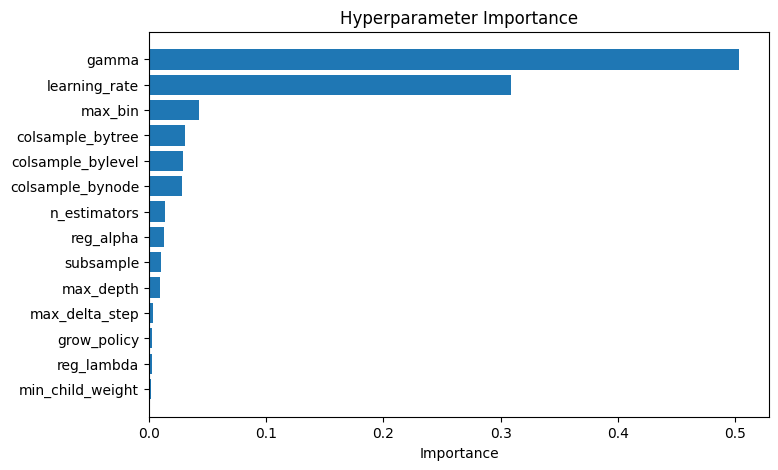

In [14]:
TRAIN_MODE = True
TUNNING_DIR = CONFIG_PATH / "optuna_search_spaces.yaml"

optuna_spaces = load_optuna_spaces(TUNNING_DIR)

if TRAIN_MODE:
    objective = create_optuna_objective(
        model_name="XGBoost",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces,   # <- con nombre, no posicional
        n_splits=5,
        cat_cols=None,                 # o la lista de categóricas si usas CatBoost
        random_state=RANDOM_STATE,
    )

    study = create_optuna_study(direction="minimize", random_state=RANDOM_STATE)

    study.optimize(objective, n_trials=150, show_progress_bar=True)

    print("Best RPS:", study.best_value)
    print("Best Params:", study.best_params)

    importances = optuna.importance.get_param_importances(study)

    plt.figure(figsize=(8, 5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()
    plt.show()




[I 2026-08-05 11:23:20,127] A new study created in memory with name: no-name-a2e1411f-a7eb-4363-8ce5-81fadff77f60
Best trial: 0. Best value: 0.196762:   1%|          | 1/150 [00:04<10:33,  4.25s/it]

[I 2026-08-05 11:23:24,376] Trial 0 finished with value: 0.1967620771717151 and parameters: {'n_estimators': 910, 'learning_rate': 0.1683243555363146, 'num_leaves': 180, 'max_depth': 6, 'min_child_samples': 10, 'subsample': 0.7545111124170836, 'colsample_bytree': 0.6065749293421778, 'feature_fraction_bynode': 0.9662533250406801, 'reg_alpha': 0.032015824430750114, 'reg_lambda': 2.7300754773418e-08, 'min_split_gain': 0.03719519116206052, 'path_smooth': 5.918694992908618, 'max_bin': 225, 'extra_trees': True}. Best is trial 0 with value: 0.1967620771717151.


Best trial: 1. Best value: 0.187603:   1%|▏         | 2/150 [00:11<14:13,  5.77s/it]

[I 2026-08-05 11:23:31,205] Trial 1 finished with value: 0.18760341193015928 and parameters: {'n_estimators': 655, 'learning_rate': 0.014334634765318594, 'num_leaves': 17, 'max_depth': 7, 'min_child_samples': 44, 'subsample': 0.6172755083585728, 'colsample_bytree': 0.9775043967143612, 'feature_fraction_bynode': 0.6988386423867478, 'reg_alpha': 0.0005846897854895608, 'reg_lambda': 1.4635241190150147e-06, 'min_split_gain': 2.943334493867249e-06, 'path_smooth': 5.5197783922675425, 'max_bin': 400, 'extra_trees': True}. Best is trial 1 with value: 0.18760341193015928.


Best trial: 2. Best value: 0.185371:   2%|▏         | 3/150 [00:13<10:18,  4.21s/it]

...

[I 2026-08-05 11:34:57,954] Trial 147 finished with value: 0.1849768729341126 and parameters: {'n_estimators': 622, 'learning_rate': 0.005228894484421631, 'num_leaves': 242, 'max_depth': 5, 'min_child_samples': 22, 'subsample': 0.6589096345585317, 'colsample_bytree': 0.9445919175454102, 'feature_fraction_bynode': 0.9143013767901591, 'reg_alpha': 0.12936469205948883, 'reg_lambda': 0.0346882182243352, 'min_split_gain': 0.25024923762148393, 'path_smooth': 2.1657826402983447, 'max_bin': 275, 'extra_trees': True}. Best is trial 74 with value: 0.1848217154552742.


Best trial: 74. Best value: 0.184822:  99%|█████████▉| 149/150 [11:40<00:03,  3.64s/it]

[I 2026-08-05 11:35:00,772] Trial 148 finished with value: 0.18863124092097625 and parameters: {'n_estimators': 373, 'learning_rate': 0.05194644911725647, 'num_leaves': 199, 'max_depth': 4, 'min_child_samples': 26, 'subsample': 0.800673445629202, 'colsample_bytree': 0.7223784374873964, 'feature_fraction_bynode': 0.6615696063020315, 'reg_alpha': 1.0564565147358215e-08, 'reg_lambda': 2.9587760586010554e-07, 'min_split_gain': 2.138938528397339e-06, 'path_smooth': 8.500706361953291, 'max_bin': 215, 'extra_trees': True}. Best is trial 74 with value: 0.1848217154552742.


Best trial: 74. Best value: 0.184822: 100%|██████████| 150/150 [11:44<00:00,  4.70s/it]


[I 2026-08-05 11:35:04,986] Trial 149 finished with value: 0.18531761133623598 and parameters: {'n_estimators': 836, 'learning_rate': 0.013915234516288651, 'num_leaves': 152, 'max_depth': 10, 'min_child_samples': 9, 'subsample': 0.8907232244154336, 'colsample_bytree': 0.5046006608267066, 'feature_fraction_bynode': 0.6400381533257016, 'reg_alpha': 0.0071254219749737075, 'reg_lambda': 4.5188137790847445e-07, 'min_split_gain': 0.21695121219578473, 'path_smooth': 5.381194305122229, 'max_bin': 258, 'extra_trees': True}. Best is trial 74 with value: 0.1848217154552742.
Best RPS: 0.1848217154552742
Best Params: {'n_estimators': 579, 'learning_rate': 0.005057436148482022, 'num_leaves': 231, 'max_depth': 4, 'min_child_samples': 15, 'subsample': 0.7231306377674226, 'colsample_bytree': 0.85888856604891, 'feature_fraction_bynode': 0.9101384014377191, 'reg_alpha': 0.07135767288231064, 'reg_lambda': 0.0004527253344442509, 'min_split_gain': 0.27755983133701795, 'path_smooth': 5.138247766389112, 'max_

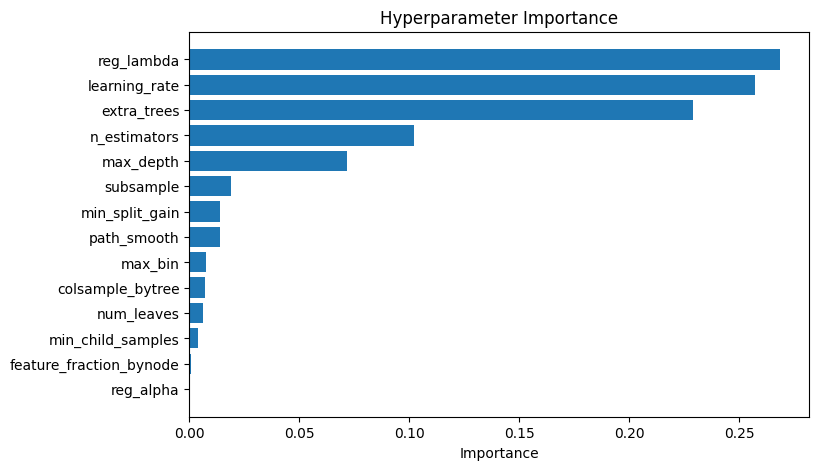

In [15]:
if TRAIN_MODE:
    objective = create_optuna_objective(
        model_name="LightGBM",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_lgbm = create_optuna_study()

    study_lgbm.optimize(
        objective,
        n_trials=150,
        show_progress_bar=True
    )

    print("Best RPS:", study_lgbm.best_value)
    print("Best Params:", study_lgbm.best_params)

    importances = get_param_importances(study_lgbm)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()


[I 2026-08-05 11:35:07,150] A new study created in memory with name: no-name-a3cc9728-0d1a-4eb8-8fa4-babc05199132
Best trial: 0. Best value: 0.233032:   1%|          | 1/100 [01:27<2:24:35, 87.63s/it]

[I 2026-08-05 11:36:34,783] Trial 0 finished with value: 0.2330318667281927 and parameters: {'iterations': 910, 'depth': 10, 'learning_rate': 0.08290691683202742, 'l2_leaf_reg': 3.088882062609849, 'random_strength': 3.467219735882505e-08, 'bagging_temperature': 1.9313889052135447, 'border_count': 104, 'leaf_estimation_iterations': 10, 'min_data_in_leaf': 73, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.2330318667281927.


Best trial: 1. Best value: 0.187427:   2%|▏         | 2/100 [01:55<1:25:20, 52.25s/it]

[I 2026-08-05 11:37:02,253] Trial 1 finished with value: 0.18742672663717166 and parameters: {'iterations': 527, 'depth': 6, 'learning_rate': 0.010788831702409045, 'l2_leaf_reg': 3.2920390689562296, 'random_strength': 2.066261611090109e-06, 'bagging_temperature': 0.055570576616259526, 'border_count': 142, 'leaf_estimation_iterations': 5, 'min_data_in_leaf': 5, 'grow_policy': 'SymmetricTree'}. Best is trial 1 with value: 0.18742672663717166.


Best trial: 1. Best value: 0.187427:   3%|▎         | 3/100 [02:22<1:05:50, 40.73s/it]

...

[I 2026-08-05 12:15:30,381] Trial 97 finished with value: 0.18607877592356487 and parameters: {'iterations': 269, 'depth': 4, 'learning_rate': 0.007135249016821269, 'l2_leaf_reg': 1.0162258732972522, 'random_strength': 0.049997465241406545, 'bagging_temperature': 4.757267033206567, 'border_count': 96, 'leaf_estimation_iterations': 5, 'min_data_in_leaf': 78, 'grow_policy': 'Depthwise'}. Best is trial 92 with value: 0.1851598847175383.


Best trial: 92. Best value: 0.18516:  99%|█████████▉| 99/100 [40:37<00:16, 16.83s/it]

[I 2026-08-05 12:15:44,440] Trial 98 finished with value: 0.18544087121828617 and parameters: {'iterations': 270, 'depth': 6, 'learning_rate': 0.008833299007241106, 'l2_leaf_reg': 3.093486451397091, 'random_strength': 0.03437601823623803, 'bagging_temperature': 3.0656665329468007, 'border_count': 204, 'leaf_estimation_iterations': 3, 'min_data_in_leaf': 53, 'grow_policy': 'Depthwise'}. Best is trial 92 with value: 0.1851598847175383.


Best trial: 92. Best value: 0.18516: 100%|██████████| 100/100 [41:00<00:00, 24.60s/it]


[I 2026-08-05 12:16:07,466] Trial 99 finished with value: 0.18516030677478487 and parameters: {'iterations': 711, 'depth': 4, 'learning_rate': 0.0051760754035006734, 'l2_leaf_reg': 5.294755513760226, 'random_strength': 0.01808907643254737, 'bagging_temperature': 3.767109937955459, 'border_count': 80, 'leaf_estimation_iterations': 2, 'min_data_in_leaf': 66, 'grow_policy': 'Lossguide'}. Best is trial 92 with value: 0.1851598847175383.
Best RPS: 0.1851598847175383
Best Params: {'iterations': 782, 'depth': 4, 'learning_rate': 0.005490823296531349, 'l2_leaf_reg': 3.0098758519310986, 'random_strength': 6.308884329473505, 'bagging_temperature': 3.3166475480935373, 'border_count': 73, 'leaf_estimation_iterations': 1, 'min_data_in_leaf': 50, 'grow_policy': 'Depthwise'}


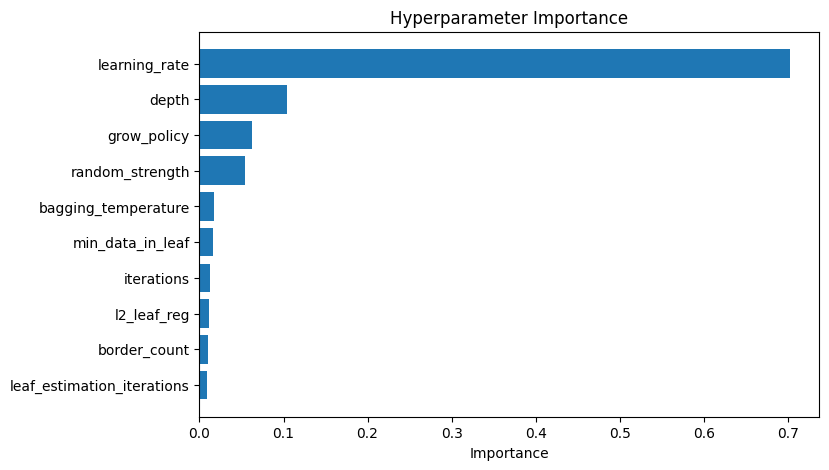

In [16]:
if TRAIN_MODE:
    objective_CAT = create_optuna_objective(
        model_name="CatBoost",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_CAT = create_optuna_study()

    study_CAT.optimize(
        objective_CAT,
        n_trials=100,
        show_progress_bar=True
    )

    print("Best RPS:", study_CAT.best_value)
    print("Best Params:", study_CAT.best_params)


    importances = get_param_importances(study_CAT)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()


[I 2026-08-05 12:16:08,817] A new study created in memory with name: no-name-c74a2e88-5df5-4d81-8bae-9a3eba0f8978
Best trial: 0. Best value: 0.18479:   1%|          | 1/150 [00:09<22:29,  9.05s/it]

[I 2026-08-05 12:16:17,863] Trial 0 finished with value: 0.18478984073466645 and parameters: {'bootstrap': False, 'n_estimators': 886, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.18478984073466645.


Best trial: 0. Best value: 0.18479:   1%|▏         | 2/150 [00:15<17:54,  7.26s/it]

[I 2026-08-05 12:16:23,877] Trial 1 finished with value: 0.18495142709238582 and parameters: {'bootstrap': True, 'n_estimators': 452, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 0.8, 'max_samples': 0.521594385448216}. Best is trial 0 with value: 0.18478984073466645.


Best trial: 0. Best value: 0.18479:   2%|▏         | 3/150 [00:23<19:02,  7.77s/it]

...

[I 2026-08-05 12:36:20,455] Trial 147 finished with value: 0.18477584788295334 and parameters: {'bootstrap': True, 'n_estimators': 250, 'max_depth': 14, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_samples': 0.6878517697921644}. Best is trial 103 with value: 0.1847536857513622.


Best trial: 103. Best value: 0.184754:  99%|█████████▉| 149/150 [20:16<00:06,  6.57s/it]

[I 2026-08-05 12:36:25,181] Trial 148 finished with value: 0.18501121676627202 and parameters: {'bootstrap': True, 'n_estimators': 392, 'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2', 'max_samples': 0.691971695846236}. Best is trial 103 with value: 0.1847536857513622.


Best trial: 103. Best value: 0.184754: 100%|██████████| 150/150 [20:18<00:00,  8.13s/it]


[I 2026-08-05 12:36:27,814] Trial 149 finished with value: 0.18500471358954682 and parameters: {'bootstrap': True, 'n_estimators': 205, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_samples': 0.7102864048217806}. Best is trial 103 with value: 0.1847536857513622.
Best RPS: 0.1847536857513622
Best Params: {'bootstrap': True, 'n_estimators': 1069, 'max_depth': 29, 'min_samples_split': 14, 'min_samples_leaf': 17, 'max_features': 0.8, 'max_samples': 0.5779245877927062}


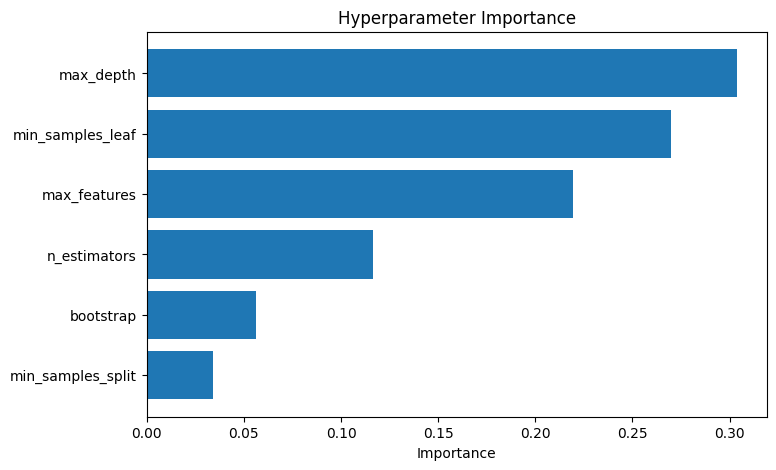

In [17]:
if TRAIN_MODE:
    objective_extra = create_optuna_objective(
        model_name="extra",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_extra = create_optuna_study()

    study_extra.optimize(
        objective_extra,
        n_trials=150,
        show_progress_bar=True
    )

    print("Best RPS:", study_extra.best_value)
    print("Best Params:", study_extra.best_params)


    importances = get_param_importances(study_extra)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()

[I 2026-08-05 12:36:29,799] A new study created in memory with name: no-name-1043493a-c07d-4ec2-b230-b8f83ad78187
Best trial: 0. Best value: 0.185585:   0%|          | 1/250 [00:12<53:15, 12.83s/it]

[I 2026-08-05 12:36:42,635] Trial 0 finished with value: 0.18558495699827898 and parameters: {'penalty': 'l2', 'C': 0.004549452186429166}. Best is trial 0 with value: 0.18558495699827898.


Best trial: 0. Best value: 0.185585:   1%|          | 2/250 [00:24<49:05, 11.88s/it]

[I 2026-08-05 12:36:53,848] Trial 1 finished with value: 0.18579273704153354 and parameters: {'penalty': 'l2', 'C': 4.5976218744590405}. Best is trial 0 with value: 0.18558495699827898.


Best trial: 0. Best value: 0.185585:   1%|          | 3/250 [00:25<28:41,  6.97s/it]

...

[I 2026-08-05 12:40:01,265] Trial 247 finished with value: 0.1854450240640493 and parameters: {'penalty': 'l1', 'C': 0.05096577737916145}. Best is trial 63 with value: 0.18542863004382798.


Best trial: 63. Best value: 0.185429: 100%|█████████▉| 249/250 [03:31<00:00,  1.44it/s]

[I 2026-08-05 12:40:01,776] Trial 248 finished with value: 0.18679685392904782 and parameters: {'penalty': 'l1', 'C': 0.009677292769102045}. Best is trial 63 with value: 0.18542863004382798.


Best trial: 63. Best value: 0.185429: 100%|██████████| 250/250 [03:32<00:00,  1.18it/s]


[I 2026-08-05 12:40:02,480] Trial 249 finished with value: 0.18550920953297714 and parameters: {'penalty': 'l1', 'C': 0.08056481994104757}. Best is trial 63 with value: 0.18542863004382798.
Best RPS: 0.18542863004382798
Best Params: {'penalty': 'l1', 'C': 0.04075607571209799}


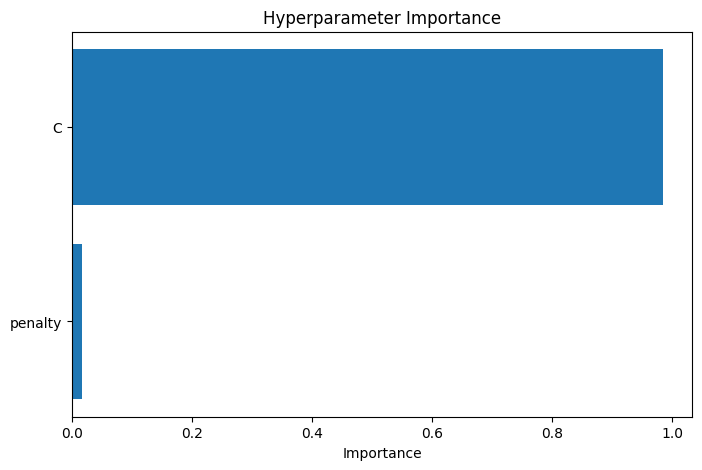

In [18]:
if TRAIN_MODE:
    objective_log = create_optuna_objective(
        model_name="Logistic",
        X=X_train_final,
        y=y_train,
        optuna_spaces=optuna_spaces, 
        n_splits=5,
        cat_cols=None,
        random_state=RANDOM_STATE
    )

    study_log = create_optuna_study()

    study_log.optimize(
        objective_log,
        n_trials=250,
        show_progress_bar=True
    )


    print("Best RPS:", study_log.best_value)
    print("Best Params:", study_log.best_params)

    importances = get_param_importances(study_log)

    plt.figure(figsize=(8,5))
    plt.barh(list(importances.keys()), list(importances.values()))
    plt.xlabel("Importance")
    plt.title("Hyperparameter Importance")
    plt.gca().invert_yaxis()

    plt.show()


In [21]:
# 1. Definir el mapeo con tus objetos de Optuna ya entrenados
studies_dict: Dict[str, optuna.Study] = {
    "LogisticRegression": study_log,
    "ExtraTrees": study_extra,
    "LightGBM": study_lgbm,
    "CatBoost": study_CAT,
    "XGBoost": study,  # 'study' ==  XGBoost
}

export_optuna_tuning_results(
    studies_dict,CONFIG_PATH, METRICS_DIR
)


 EXPORTANDO RESULTADOS DE OPTUNA Y CONFIGURACIONES YAML
 [YAML] Parámetros guardados para 'LogisticRegression' -> best_params_logisticregression.yaml
 [YAML] Parámetros guardados para 'ExtraTrees' -> best_params_extratrees.yaml
 [YAML] Parámetros guardados para 'LightGBM' -> best_params_lightgbm.yaml
 [YAML] Parámetros guardados para 'CatBoost' -> best_params_catboost.yaml
 [YAML] Parámetros guardados para 'XGBoost' -> best_params_xgboost.yaml
------------------------------------------------------------
[EXITO] Resumen de validación guardado en JSON:
 -> c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\tunned_models_validation_results.json



### Checkpoint on YAML hypertunned models

In [26]:
_CANONICAL_MODEL_NAMES: Dict[str, str] = {
    "catboost": "CatBoost",
    "extratrees": "ExtraTrees",
    "lightgbm": "LightGBM",
    "logisticregression": "LogisticRegression",
    "xgboost": "XGBoost",
}

# Parametros que train_and_evaluate_hardcoded ya inyecta al construir cada
# modelo. Si tambien vinieran del YAML, Python lanzaria
# "got multiple values for keyword argument".
_INJECTED_PARAMS: Dict[str, List[str]] = {
    "CatBoost": ["loss_function", "random_seed", "verbose"],
    "ExtraTrees": ["random_state", "n_jobs"],
    "LightGBM": ["objective", "num_class", "random_state", "n_jobs"],
    "LogisticRegression": [],
    "XGBoost": [
        "objective", "num_class", "tree_method", "random_state", "n_jobs",
    ],
}

def _sanitize_params(params: Dict[str, Any]) -> Dict[str, Any]:
    """Convierte tipos de NumPy/Optuna a tipos nativos de Python (int, float,

    bool) para asegurar compatibilidad total con JSON y YAML.
    """
    clean_params: Dict[str, Any] = {}
    key: str
    val: Any
    for key, val in params.items():
        # bool va primero: isinstance(True, int) es True en Python, asi que el
        # orden inverso degradaria los booleanos a 1/0 y sklearn los rechaza
        # ("The 'bootstrap' parameter ... must be an instance of 'bool'").
        if isinstance(val, (np.bool_, bool)):
            clean_params[key] = bool(val)
        elif isinstance(val, (np.integer, int)):
            clean_params[key] = int(val)
        elif isinstance(val, (np.floating, float)):
            clean_params[key] = float(val)
        else:
            clean_params[key] = val
    return clean_params
    
def export_optuna_tuning_results(
    studies_map: Dict[str, optuna.Study],
    CONFIG_DIR: Union[str, Path],
    METRICS_DIR: Union[str, Path]
) -> None:
    """Exporta los resultados del tuning de Optuna:

    1. Un archivo JSON único con el resumen de métricas (best_rps) y parámetros.
    2. Archivos YAML individuales de configuración con los mejores
    hiperparámetros de cada modelo.
    """

    json_results: Dict[str, Dict[str, Any]] = {}

    print("\n" + "=" * 60)
    print(" EXPORTANDO RESULTADOS DE OPTUNA Y CONFIGURACIONES YAML")
    print("=" * 60)

    model_name: str
    study_obj: optuna.Study
    for model_name, study_obj in studies_map.items():
        best_value: float = float(study_obj.best_value)
        best_params: Dict[str, Any] = _sanitize_params(study_obj.best_params)

        # 1. Estructurar la entrada para el archivo JSON unificado
        json_results[model_name] = {
            "best_rps": round(best_value, 6),
            "best_params": best_params,
        }

        # 2. Exportar archivo YAML individual con los mejores parámetros
        yaml_filename: str = f"best_params_{model_name.lower()}.yaml"
        yaml_path: Path = CONFIG_DIR / yaml_filename

        with open(yaml_path, "w", encoding="utf-8") as f:
            yaml.dump(
                best_params, f, default_flow_style=False, sort_keys=False
            )

        print(
            f" [YAML] Parámetros guardados para '{model_name}' -> {yaml_path.name}"
        )

    # 3. Exportar archivo JSON unificado con las métricas de validación
    json_path: Path = METRICS_DIR / "tunned_models_validation_results.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(json_results, f, indent=4)

    print("-" * 60)
    print(
        f"[EXITO] Resumen de validación guardado en JSON:\n -> {json_path}\n"
    )

In [29]:
BEST_PARAMS_DICT = load_best_params(CONFIG_PATH)

val_results = {}

for model_name in BEST_PARAMS_DICT.keys():
    print(f"\nTraining {model_name} with frozen parameters...")

    res = train_and_evaluate_hardcoded(
        model_name=model_name,
        X_train=X_train_final,
        y_train=y_train,
        X_val=X_val_final,
        y_val=y_val,
        cat_cols=None,
        best_params_dict=BEST_PARAMS_DICT,
        RANDOM_STATE=RANDOM_STATE,
    )

    val_results[model_name] = res
    print(f"{model_name} VAL RPS: {res['val_rps']:.5f}")

 [OK] CatBoost: 10 parametros <- best_params_catboost.yaml
 [OK] ExtraTrees: 7 parametros <- best_params_extratrees.yaml
 [OK] LightGBM: 14 parametros <- best_params_lightgbm.yaml
 [OK] LogisticRegression: 3 parametros <- best_params_logisticregression.yaml
 [OK] XGBoost: 14 parametros <- best_params_xgboost.yaml

Training CatBoost with frozen parameters...
CatBoost VAL RPS: 0.18577

Training ExtraTrees with frozen parameters...
ExtraTrees VAL RPS: 0.18525

Training LightGBM with frozen parameters...
LightGBM VAL RPS: 0.18482

Training LogisticRegression with frozen parameters...
LogisticRegression VAL RPS: 0.18677

Training XGBoost with frozen parameters...
XGBoost VAL RPS: 0.18523


### Error Analysis

Metadata loaded. Columns available for analysis: ['match_id', 'match_datetime_utc', 'season_id', 'home_team_id', 'away_team_id', 'home_score', 'away_score', 'home_venue_id', 'home_referee_id', 'home_macro_rolling_goals']...
STARTING ERROR ANALYSIS PIPELINE...
Validation Set Size: 2369 matches

TEST 6: Consensus & Ensemble Potential
GOAL: Check if models agree. Low correlation = High Ensemble Potential.


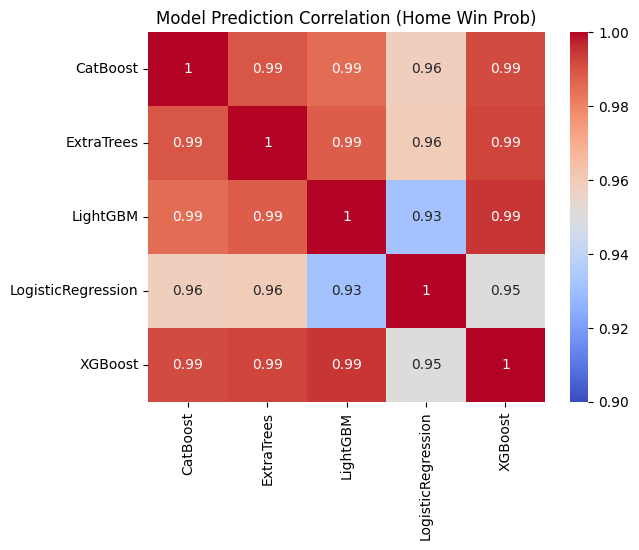

Average Correlation: 0.9741

TEST 1: Reliability & Calibration Analysis
GOAL: Determine if '70% confidence' actually means 70% win rate.
[CatBoost] Home Win Brier Score: 0.1936
[ExtraTrees] Home Win Brier Score: 0.1926
[LightGBM] Home Win Brier Score: 0.1918
[LogisticRegression] Home Win Brier Score: 0.1961
[XGBoost] Home Win Brier Score: 0.1922


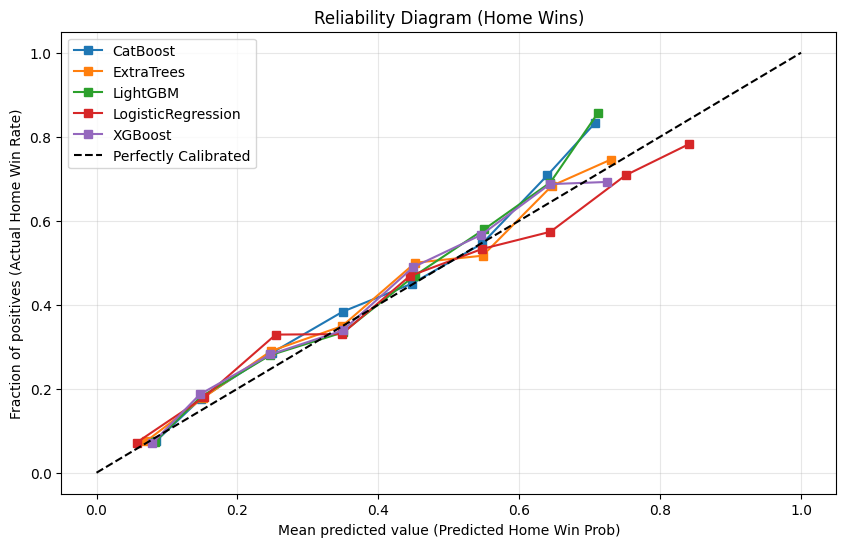


TEST 3: Tournament Segmented Performance
GOAL: Identify which leagues/cups we fail to predict.
Analysis using model: CatBoost
                         RPS  Count
tournament                         
community-shield    0.346105      1
coupe_de_france     0.221598    149
bundesliga          0.199643    306
premier-league      0.193855    380
serie-a             0.187158    380
copa-del-rey        0.185144     17
italian-supercup    0.184808      6
laliga              0.183137    380
uefa-europa-league  0.179456    189
ligue-1             0.176517    306

TEST 4: Data Blindspots (Feature Slicing)
GOAL: Find non-linear weaknesses in specific scenarios.


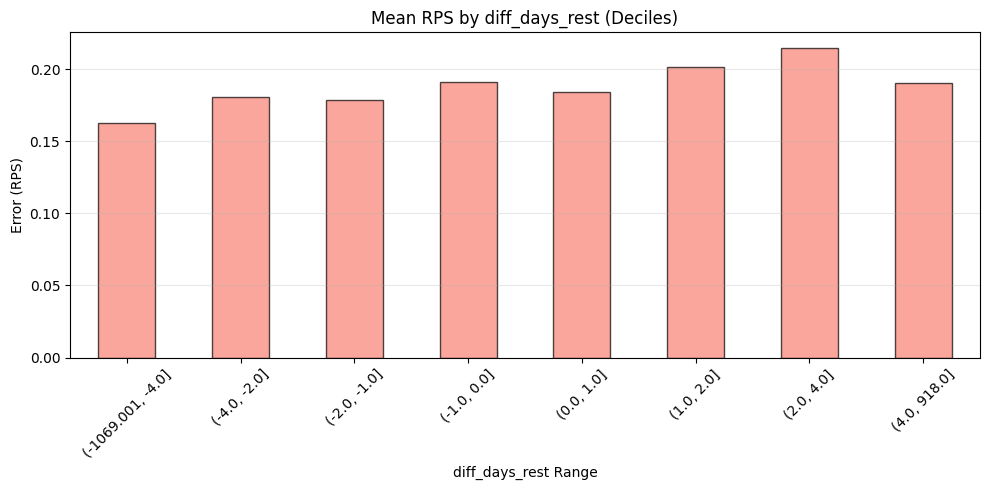

-> Plotted error distribution for diff_days_rest


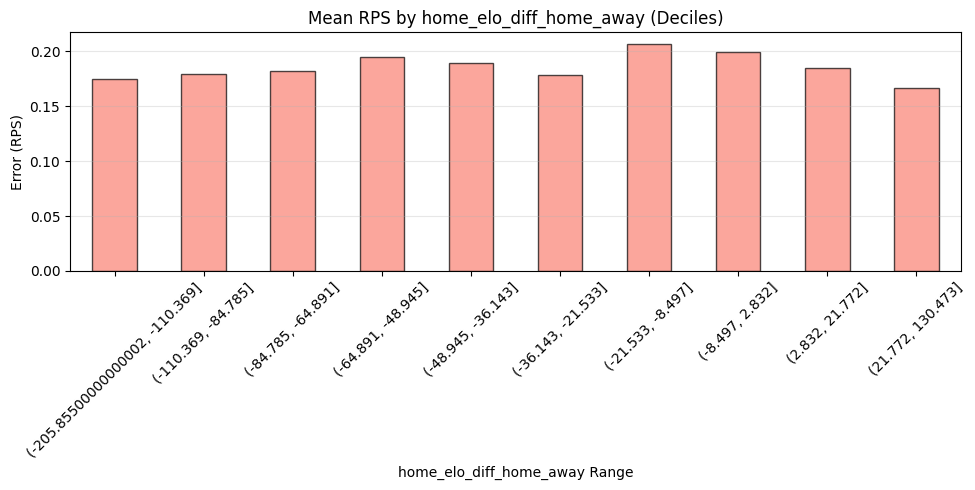

-> Plotted error distribution for home_elo_diff_home_away


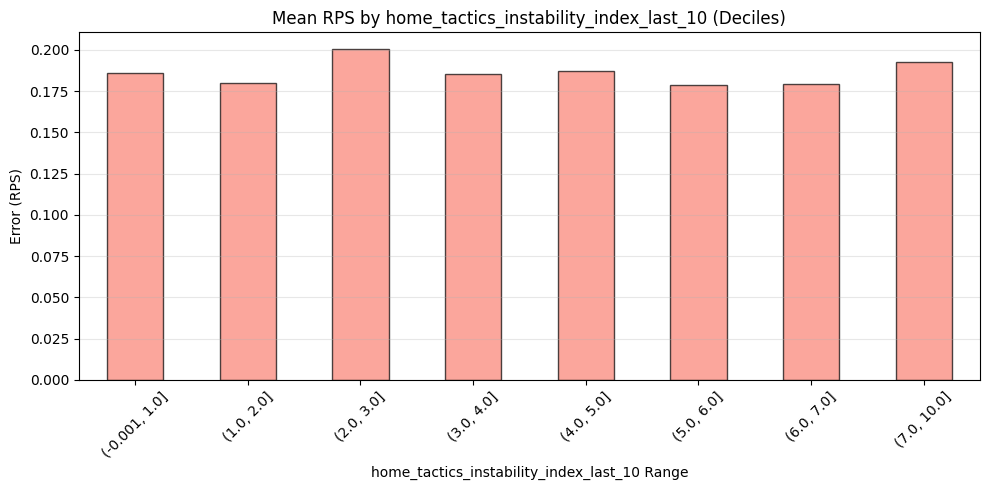

-> Plotted error distribution for home_tactics_instability_index_last_10

TEST 5: Expected Calibration Error by Category
GOAL: Measure calibration quality for each model within each category.

Top 20 worst calibrated segments (MacroAvg):


,tournament,Model,Outcome,Samples,ECE
102,coupe_de_france,LogisticRegression,MacroAvg,149,0.186311
6,coupe_de_france,CatBoost,MacroAvg,149,0.122612
122,uefa-champions-league,LogisticRegression,MacroAvg,189,0.084648
38,coupe_de_france,ExtraTrees,MacroAvg,149,0.083844
134,coupe_de_france,XGBoost,MacroAvg,149,0.083006
58,uefa-champions-league,ExtraTrees,MacroAvg,189,0.075154
154,uefa-champions-league,XGBoost,MacroAvg,189,0.073774
26,uefa-champions-league,CatBoost,MacroAvg,189,0.068149
90,uefa-champions-league,LightGBM,MacroAvg,189,0.066285
70,coupe_de_france,LightGBM,MacroAvg,149,0.063404


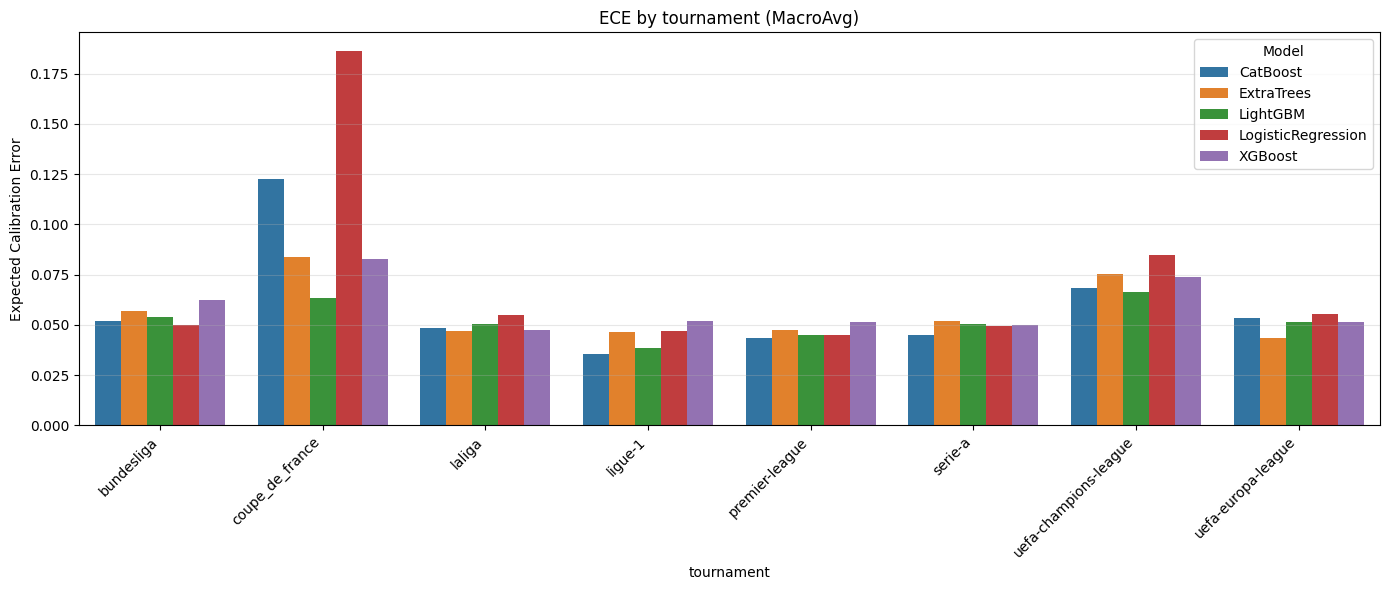


PIPELINE COMPLETE


In [30]:
model_predictions = {}

for name, result in val_results.items():

    if not isinstance(result, dict):
        raise TypeError(f"{name} result is not a dict")

    if "val_probs" not in result:
        raise KeyError(f"{name} missing val_probs")

    probs = result["val_probs"]

    if not isinstance(probs, np.ndarray):
        raise TypeError(f"{name} val_probs is not ndarray, got {type(probs)}")

    model_predictions[name] = probs

val_metadata_df = df.loc[X_val_final.index].copy()

# OPTIONAL: Sanity check to ensure lengths match
assert len(val_metadata_df) == len(list(model_predictions.values())[0]), \
    "Error: Metadata length does not match prediction length!"

print(f"Metadata loaded. Columns available for analysis: {val_metadata_df.columns.tolist()[:10]}...")

# ==============================================================================
# STEP 3: Run the Analysis Pipeline
# ==============================================================================
analyzer = SoccerModelErrorAnalyzer(
    val_df=val_metadata_df,
    y_true=y_val,
    model_preds_dict=model_predictions,
    outcomes_order=['D', 'W', 'L']
)
# Execute the plan
analyzer.run_pipeline()



### Error Interceptions

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 0. SETUP: Use only VAL set data (NO leakage)
# ============================================================================

# Extract predictions from previous step
models = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']
val_probs = {name: val_results[name]['val_probs'] for name in models}
val_preds = {name: np.argmax(val_results[name]['val_probs'], axis=1) for name in models}

# True outcomes (0=Draw, 1=Home, 2=Away)
y_true = y_val.values

# ============================================================================
# 1. STRATIFIED FAILURES: Where do models disagree?
# ============================================================================

print("="*70)
print("1. DISAGREEMENT ANALYSIS (Hard vs Easy Matches)")
print("="*70)

# Calculate prediction entropy (uncertainty) per model
def calc_entropy(probs):
    """Calculate prediction entropy: higher = more uncertain"""
    return -np.sum(probs * np.log(probs + 1e-10), axis=1)

uncertainty = {name: calc_entropy(val_probs[name]) for name in models}

# Identify hard matches: where models disagree on winner
winners = np.array([np.argmax(val_probs[m], axis=1) for m in models])
disagreement_mask = np.array([len(set(winners[:, i])) > 1 for i in range(len(y_true))])
unanimous_mask = ~disagreement_mask

print(f"Matches with model disagreement: {disagreement_mask.sum()} ({disagreement_mask.mean()*100:.1f}%)")
print(f"Unanimous predictions: {unanimous_mask.sum()} ({unanimous_mask.mean()*100:.1f}%)")

# Performance on hard vs easy matches
for name in models:
    hard_rps = evaluate_model(y_true[disagreement_mask], val_probs[name][disagreement_mask])['rps']
    easy_rps = evaluate_model(y_true[unanimous_mask], val_probs[name][unanimous_mask])['rps']
    print(f"{name:12} | Hard RPS: {hard_rps:.4f} | Easy RPS: {easy_rps:.4f} | Gap: {hard_rps-easy_rps:+.4f}")

# Check if models fail on same matches
failures = {}
for name in models:
    pred_class = np.argmax(val_probs[name], axis=1)
    failures[name] = (pred_class != y_true)

failure_overlap = np.zeros((len(models), len(models)))
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        # Jaccard similarity of failure sets
        intersection = np.sum(failures[m1] & failures[m2])
        union = np.sum(failures[m1] | failures[m2])
        failure_overlap[i, j] = intersection / union if union > 0 else 0

failure_df = pd.DataFrame(failure_overlap, index=models, columns=models)
print("\nFailure Overlap (Jaccard Index) - Higher = models fail on same matches:")
print(failure_df.round(3))





1. DISAGREEMENT ANALYSIS (Hard vs Easy Matches)
Matches with model disagreement: 295 (12.5%)
Unanimous predictions: 2074 (87.5%)
CatBoost     | Hard RPS: 0.2185 | Easy RPS: 0.1811 | Gap: +0.0374
XGBoost      | Hard RPS: 0.2138 | Easy RPS: 0.1812 | Gap: +0.0326
LightGBM     | Hard RPS: 0.2104 | Easy RPS: 0.1812 | Gap: +0.0293
ExtraTrees   | Hard RPS: 0.2157 | Easy RPS: 0.1809 | Gap: +0.0348
LogisticRegression | Hard RPS: 0.2301 | Easy RPS: 0.1806 | Gap: +0.0495

Failure Overlap (Jaccard Index) - Higher = models fail on same matches:
                    CatBoost  XGBoost  LightGBM  ExtraTrees  \
CatBoost               1.000    0.943     0.950       0.940   
XGBoost                0.943    1.000     0.969       0.941   
LightGBM               0.950    0.969     1.000       0.943   
ExtraTrees             0.940    0.941     0.943       1.000   
LogisticRegression     0.873    0.847     0.845       0.874   

                    LogisticRegression  
CatBoost                         0.873  
X

### Models Correlations

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# Stack validation probabilities: shape (n_samples, n_models, n_classes)
val_probs = np.stack([
    val_results['CatBoost']['val_probs'],
    val_results['XGBoost']['val_probs'],      
    val_results['LightGBM']['val_probs'],
    val_results['ExtraTrees']['val_probs'],
    val_results['LogisticRegression']['val_probs'],
], axis=1)

# Calculate correlation matrices per class
models = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']
n_models = len(models)

print("="*60)
print("PREDICTION CORRELATION ANALYSIS (Validation Set)")
print("="*60)

for class_idx, class_name in enumerate(['Draw', 'Home', 'Away']):
    print(f"\n{class_name} Win Probability Correlations:")
    corr_matrix = np.zeros((n_models, n_models))

    for i in range(n_models):
        for j in range(n_models):
            # Pearson correlation of predicted probabilities for this class
            corr, _ = pearsonr(val_probs[:, i, class_idx], val_probs[:, j, class_idx])
            corr_matrix[i, j] = corr

    corr_df = pd.DataFrame(corr_matrix, index=models, columns=models)
    print(corr_df.round(3))

    # Check average correlation (lower = more diversity)
    avg_corr = np.mean(corr_matrix[np.triu_indices(n_models, k=1)])
    print(f"Average pairwise correlation: {avg_corr:.3f}")

# Check rank correlation (Spearman) - important for RPS since it depends on ordering
print("\n" + "="*60)
print("RANK CORRELATION (Spearman) - Key for RPS Improvement")
print("="*60)

# For RPS, we care about the ranking of Home/Draw/Away within each match
# High rank correlation = models agree on which outcome is most likely
rank_agreement = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        # Correlation of predicted class ranks per sample
        ranks_i = np.argsort(np.argsort(val_probs[:, i], axis=1), axis=1)
        ranks_j = np.argsort(np.argsort(val_probs[:, j], axis=1), axis=1)
        # Average correlation across samples
        corrs = [spearmanr(ranks_i[k], ranks_j[k])[0] for k in range(len(ranks_i))]
        rank_agreement[i, j] = np.mean(corrs)

rank_df = pd.DataFrame(rank_agreement, index=models, columns=models)
print(rank_df.round(3))

# Diversity Score: Lower off-diagonal = better ensemble potential
diversity_score = 1 - np.mean(rank_agreement[np.triu_indices(n_models, k=1)])
print(f"\nEnsemble Diversity Score: {diversity_score:.3f}")
print("Interpretation: >0.15 high diversity, <0.05 low diversity (diminishing returns)")

PREDICTION CORRELATION ANALYSIS (Validation Set)

Draw Win Probability Correlations:
                    CatBoost  XGBoost  LightGBM  ExtraTrees  \
CatBoost               1.000    0.968     0.987       0.949   
XGBoost                0.968    1.000     0.985       0.969   
LightGBM               0.987    0.985     1.000       0.964   
ExtraTrees             0.949    0.969     0.964       1.000   
LogisticRegression     0.892    0.905     0.907       0.908   

                    LogisticRegression  
CatBoost                         0.892  
XGBoost                          0.905  
LightGBM                         0.907  
ExtraTrees                       0.908  
LogisticRegression               1.000  
Average pairwise correlation: 0.943

Home Win Probability Correlations:
                    CatBoost  XGBoost  LightGBM  ExtraTrees  \
CatBoost               1.000    0.992     0.987       0.988   
XGBoost                0.992    1.000     0.996       0.993   
LightGBM               0.987 

### Calibration Problem?


2. CALIBRATION ANALYSIS


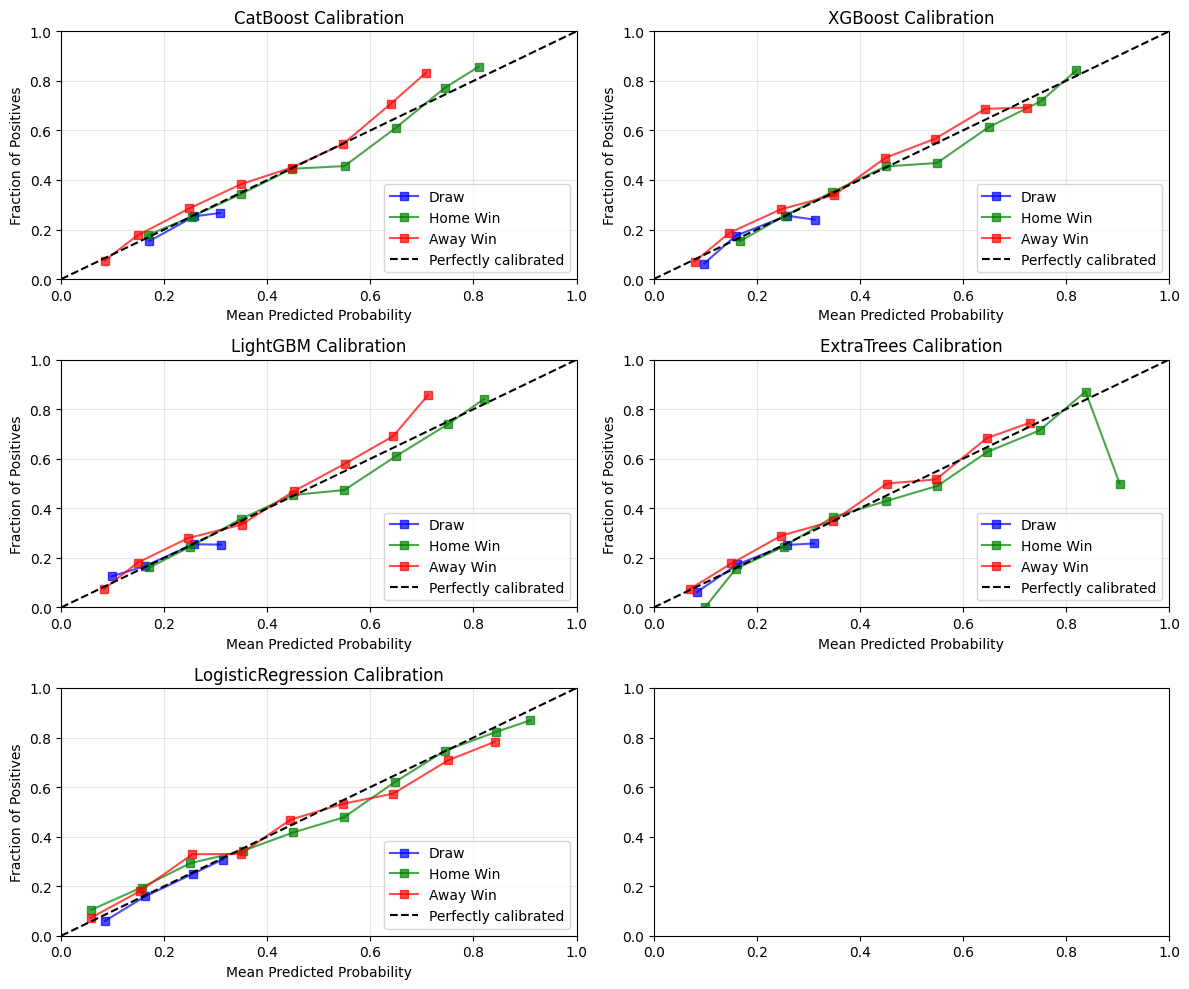

In [33]:
print("\n" + "="*70)
print("2. CALIBRATION ANALYSIS")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, name in enumerate(models):
    ax = axes[idx]

    # For each outcome (H/D/A), plot calibration curve
    outcomes = ['Draw', 'Home Win', 'Away Win']
    colors = ['blue', 'green', 'red']

    for outcome_idx, (outcome, color) in enumerate(zip(outcomes, colors)):
        y_true_binary = (y_true == outcome_idx).astype(int)
        prob_pred = val_results[name]["val_probs"][:, outcome_idx]

        # Only plot if we have enough variance
        if prob_pred.std() > 0.01:
            fraction_of_positives, mean_predicted_value = calibration_curve(
                y_true_binary, prob_pred, n_bins=10, strategy='uniform'
            )

            ax.plot(mean_predicted_value, fraction_of_positives, "s-",
                   label=outcome, color=color, alpha=0.7)

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"{name} Calibration")
    ax.legend(loc="lower right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(METRICS_DIR / 'calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



### Odds Based Strength

In [34]:
print("\n" + "="*70)
print("3. PERFORMANCE BY MATCH DIFFICULTY (Odds-based)")
print("="*70)

if 'odds_home' in X_val.columns and 'odds_away' in X_val.columns:
    # Convert odds to implied probabilities (with margin correction)
    implied_home = 1 / X_val['odds_home'].values
    implied_away = 1 / X_val['odds_away'].values
    # Favorite strength = max implied probability
    favorite_strength = np.maximum(implied_home, implied_away)
else:
    # Fallback: use max predicted probability across models as proxy
    avg_probs = np.mean(
    [val_results[m]["val_probs"] for m in models],
    axis=0
)
    favorite_strength = np.max(avg_probs, axis=1)

# Create buckets
buckets = pd.qcut(favorite_strength, q=5, labels=['Coin Flip', 'Slight Fav', 'Moderate Fav', 'Strong Fav', 'Heavy Fav'])
bucket_performance = {}

for name in models:
    bucket_rps = []
    for bucket in ['Coin Flip', 'Slight Fav', 'Moderate Fav', 'Strong Fav', 'Heavy Fav']:
        mask = buckets == bucket
        if mask.sum() > 0:
            rps = evaluate_model(
                y_true[mask],
                val_results[name]["val_probs"][mask]
            )['rps']
            bucket_rps.append(rps)
        else:
            bucket_rps.append(np.nan)
    bucket_performance[name] = bucket_rps

bucket_df = pd.DataFrame(bucket_performance,
                        index=['Coin Flip', 'Slight Fav', 'Moderate Fav', 'Strong Fav', 'Heavy Fav'])
print("\nRPS by Match Difficulty (lower = better):")
print(bucket_df.round(4))

# Check if any model dominates specific buckets
best_per_bucket = bucket_df.idxmin(axis=1)
print(f"\nBest model per bucket:\n{best_per_bucket}")

if best_per_bucket.nunique() > 1:
    print("  Different models excel in different scenarios. Weighted ensemble recommended.")
else:
    print(f"   {best_per_bucket.iloc[0]} dominates all buckets. Single model may suffice.")


3. PERFORMANCE BY MATCH DIFFICULTY (Odds-based)

RPS by Match Difficulty (lower = better):
              CatBoost  XGBoost  LightGBM  ExtraTrees  LogisticRegression
Coin Flip       0.2153   0.2135    0.2115      0.2147              0.2206
Slight Fav      0.2113   0.2107    0.2104      0.2102              0.2127
Moderate Fav    0.2044   0.2041    0.2044      0.2041              0.2041
Strong Fav      0.1799   0.1798    0.1797      0.1792              0.1794
Heavy Fav       0.1180   0.1180    0.1182      0.1180              0.1171

Best model per bucket:
Coin Flip                 LightGBM
Slight Fav              ExtraTrees
Moderate Fav            ExtraTrees
Strong Fav              ExtraTrees
Heavy Fav       LogisticRegression
dtype: object
  Different models excel in different scenarios. Weighted ensemble recommended.


### Temporal Analysis

In [37]:
df_prepared['match_datetime_utc'] = pd.to_datetime(
    df_prepared['match_datetime_utc'],
    format='ISO8601'
)

df_prepared['week'] = df_prepared['match_datetime_utc'].dt.isocalendar().week

df_prepared['month'] = df_prepared['match_datetime_utc'].dt.month

df_prepared['quarter'] = df_prepared['match_datetime_utc'].dt.quarter


variables = list(X_val.columns) + ['quarter']


### Bias Analysis

In [38]:
print("\n" + "="*70)
print("5. SYSTEMATIC BIAS ANALYSIS")
print("="*70)

draw_matches= y_true == 0
home_matches = y_true == 1
away_matches = y_true == 2

print("\nRPS by Actual Result:")

bias_report = {}

for name in models:

    probs = val_results[name]["val_probs"]

    home_rps = evaluate_model(y_true[home_matches], probs[home_matches])['rps']
    draw_rps = evaluate_model(y_true[draw_matches], probs[draw_matches])['rps']
    away_rps = evaluate_model(y_true[away_matches], probs[away_matches])['rps']

    bias_report[name] = {
        'Home': home_rps,
        'Draw': draw_rps,
        'Away': away_rps
    }

    print(f"{name:12} | Home: {home_rps:.4f} | Draw: {draw_rps:.4f} | Away: {away_rps:.4f}")

bias_df = pd.DataFrame(bias_report).T

# ---------------------------------------------------
# Favorite vs Underdog Bias
# ---------------------------------------------------

print("\nAccuracy when predicting Favorite (prob > 0.5) vs Underdog:")

for name in models:

    pred_probs = val_results[name]["val_probs"]

    max_probs = np.max(pred_probs, axis=1)
    pred_classes = np.argmax(pred_probs, axis=1)

    high_conf = max_probs > 0.5

    if high_conf.sum() > 0:

        acc_high = (pred_classes[high_conf] == y_true[high_conf]).mean()
        acc_low = (pred_classes[~high_conf] == y_true[~high_conf]).mean()

        print(f"{name:12} | High Conf (>0.5): {acc_high:.3f} | "
              f"Low Conf: {acc_low:.3f} | Gap: {acc_high-acc_low:+.3f}")


5. SYSTEMATIC BIAS ANALYSIS

RPS by Actual Result:
CatBoost     | Home: 0.0697 | Draw: 0.3455 | Away: 0.2217
XGBoost      | Home: 0.0689 | Draw: 0.3492 | Away: 0.2185
LightGBM     | Home: 0.0691 | Draw: 0.3506 | Away: 0.2161
ExtraTrees   | Home: 0.0695 | Draw: 0.3485 | Away: 0.2184
LogisticRegression | Home: 0.0705 | Draw: 0.3513 | Away: 0.2195

Accuracy when predicting Favorite (prob > 0.5) vs Underdog:
CatBoost     | High Conf (>0.5): 0.617 | Low Conf: 0.429 | Gap: +0.188
XGBoost      | High Conf (>0.5): 0.621 | Low Conf: 0.441 | Gap: +0.180
LightGBM     | High Conf (>0.5): 0.622 | Low Conf: 0.433 | Gap: +0.189
ExtraTrees   | High Conf (>0.5): 0.620 | Low Conf: 0.437 | Gap: +0.183
LogisticRegression | High Conf (>0.5): 0.611 | Low Conf: 0.422 | Gap: +0.189


In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd


# =============================================================================
# 1. PREPARE META FEATURES
# =============================================================================
model_names = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees', 'LogisticRegression']

val_prob_dict = {
    name: val_results[name]['val_probs']
    for name in model_names
}

y_meta = y_val.values

# =============================================================================
# 2. BASELINE ENSEMBLES
# =============================================================================
print("\n" + "=" * 60)
print("BASELINE ENSEMBLES")
print("=" * 60)

stacked_probs = np.stack(
    [val_prob_dict[m] for m in model_names],
    axis=0
)

baselines = {
    'Simple_Average': np.mean(stacked_probs, axis=0),
    'Median_Ensemble': np.median(stacked_probs, axis=0),
    'Best_Single_CatBoost': val_prob_dict['CatBoost'],
}

baseline_results = {}

for name, probs in baselines.items():
    metrics = evaluate_model(y_meta, probs)
    baseline_results[name] = metrics

    print(
        f"{name:25} | "
        f"RPS: {metrics['rps']:.5f} | "
        f"LogLoss: {metrics['log_loss']:.5f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"ECE: {metrics['ece']:.5f}"
    )


print("\n" + "=" * 60)
print("FULL COMPARISON")
print("=" * 60)

all_results = {
    **{
        f"[Base] {name}": metrics
        for name, metrics in baseline_results.items()
    },

}

sorted_results = sorted(
    all_results.items(),
    key=lambda x: x[1]['rps']
)

print(
    f"\n{'Model':35} | "
    f"{'RPS':>10} | "
    f"{'LogLoss':>10} | "
    f"{'Accuracy':>10} | "
    f"{'ECE':>10}"
)
print("-" * 100)

for name, metrics in sorted_results:
    print(
        f"{name:35} | "
        f"{metrics['rps']:>10.5f} | "
        f"{metrics['log_loss']:>10.5f} | "
        f"{metrics['accuracy']:>10.4f} | "
        f"{metrics['ece']:>10.5f}"
    )


BASELINE ENSEMBLES
Simple_Average            | RPS: 0.18513 | LogLoss: 0.97560 | Acc: 0.5386 | ECE: 0.01567
Median_Ensemble           | RPS: 0.18513 | LogLoss: 0.97601 | Acc: 0.5399 | ECE: 0.01552
Best_Single_CatBoost      | RPS: 0.18577 | LogLoss: 0.97905 | Acc: 0.5348 | ECE: 0.01920

FULL COMPARISON

Model                               |        RPS |    LogLoss |   Accuracy |        ECE
----------------------------------------------------------------------------------------------------
[Base] Median_Ensemble              |    0.18513 |    0.97601 |     0.5399 |    0.01552
[Base] Simple_Average               |    0.18513 |    0.97560 |     0.5386 |    0.01567
[Base] Best_Single_CatBoost         |    0.18577 |    0.97905 |     0.5348 |    0.01920


### Test Results

In [42]:
import torch
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss, accuracy_score


# =============================================================================
# 1. BASE MODELS ON TEST
# =============================================================================
print("=" * 90)
print("TEST SET EVALUATION — BASE MODELS")
print("=" * 90)

X_test_final = X_test[final_features].copy()
y_test_array = y_test.values.copy()

test_probs = {}
test_metrics = {}

for name, res in val_results.items():
    model = res['model']
    probs = model.predict_proba(X_test_final)

    test_probs[name] = probs
    metrics = evaluate_model(y_test_array, probs)
    test_metrics[name] = metrics

    print(
        f"{name:25} | "
        f"RPS: {metrics['rps']:.5f} | "
        f"LogLoss: {metrics['log_loss']:.5f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"ECE: {metrics['ece']:.5f}"
    )


# =============================================================================
# 2. SIMPLE ENSEMBLES
# =============================================================================
print("\n" + "=" * 90)
print("TEST SET EVALUATION — SIMPLE ENSEMBLES")
print("=" * 90)

ensemble_names = ['CatBoost', 'XGBoost', 'LightGBM', 'ExtraTrees']

stacked_test = np.stack(
    [test_probs[n] for n in ensemble_names],
    axis=0
)

simple_ensembles = {
    'Simple_Average': np.mean(stacked_test, axis=0),
    'Median_Ensemble': np.median(stacked_test, axis=0),
    'All_Models_Avg': np.mean(
        np.stack(list(test_probs.values()), axis=0),
        axis=0
    ),
}

for name, probs in simple_ensembles.items():
    metrics = evaluate_model(y_test_array, probs)
    test_metrics[name] = metrics

    print(
        f"{name:25} | "
        f"RPS: {metrics['rps']:.5f} | "
        f"LogLoss: {metrics['log_loss']:.5f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"ECE: {metrics['ece']:.5f}"
    )



# =============================================================================
# 4. VALIDATION REFERENCES
# =============================================================================
val_prob_stack = np.stack(
    [val_results[n]['val_probs'] for n in ensemble_names],
    axis=0
)

simple_ensembles_val = {
    'Simple_Average': np.mean(val_prob_stack, axis=0),
    'Median_Ensemble': np.median(val_prob_stack, axis=0),
    'All_Models_Avg': np.mean(
        np.stack(
            [val_results[n]['val_probs'] for n in val_results],
            axis=0
        ),
        axis=0
    ),
}

# Validation RPS reference
val_rps_ref = {
    name: val_results[name]['val_rps']
    for name in val_results
}

val_rps_ref.update({
    name: np.mean(get_vectorized_rps(probs, y_val.values))
    for name, probs in simple_ensembles_val.items()
})



# Validation ECE reference
val_ece_ref = {
    name: calculate_ece(y_val.values, val_results[name]['val_probs'])
    for name in val_results
}

val_ece_ref.update({
    name: calculate_ece(y_val.values, probs)
    for name, probs in simple_ensembles_val.items()
})



# =============================================================================
# 5. FINAL COMPARISON
# =============================================================================
print("\n" + "=" * 120)
print("FINAL COMPARISON — VAL vs TEST")
print("=" * 120)

print(
    f"\n{'Model':32} | "
    f"{'Val RPS':>10} | "
    f"{'Test RPS':>10} | "
    f"{'Δ RPS':>10} | "
    f"{'Val ECE':>10} | "
    f"{'Test ECE':>10} | "
    f"{'Status':>15}"
)
print("-" * 120)

sorted_models = sorted(
    test_metrics.items(),
    key=lambda x: x[1]['rps']
)

for name, metrics in sorted_models:
    val_rps = val_rps_ref.get(name, np.nan)
    test_rps = metrics['rps']
    delta_rps = test_rps - val_rps

    val_ece = val_ece_ref.get(name, np.nan)
    test_ece = metrics['ece']

    if delta_rps > 0.01:
        status = "[OVERFIT]"
    elif test_ece > 0.08:
        status = "[POOR_CALIBRATION]"
    else:
        status = "[STABLE]"

    print(
        f"{name:32} | "
        f"{val_rps:10.5f} | "
        f"{test_rps:10.5f} | "
        f"{delta_rps:+10.5f} | "
        f"{val_ece:10.5f} | "
        f"{test_ece:10.5f} | "
        f"{status:>15}"
    )


# =============================================================================
# 6. BEST MODEL SUMMARY
# =============================================================================
best_test_model = min(test_metrics, key=lambda n: test_metrics[n]['rps'])
best_metrics = test_metrics[best_test_model]

print("\n" + "=" * 90)
print("[GANADOR] BEST MODEL ON TEST")
print("=" * 90)
print(f"Model    : {best_test_model}")
print(f"RPS      : {best_metrics['rps']:.5f}")
print(f"LogLoss  : {best_metrics['log_loss']:.5f}")
print(f"Accuracy : {best_metrics['accuracy']:.4f}")
print(f"ECE      : {best_metrics['ece']:.5f}")

TEST SET EVALUATION — BASE MODELS
CatBoost                  | RPS: 0.18229 | LogLoss: 0.97687 | Acc: 0.5367 | ECE: 0.02906
ExtraTrees                | RPS: 0.18186 | LogLoss: 0.97376 | Acc: 0.5387 | ECE: 0.02602
LightGBM                  | RPS: 0.18224 | LogLoss: 0.97603 | Acc: 0.5375 | ECE: 0.02455
LogisticRegression        | RPS: 0.18310 | LogLoss: 0.98505 | Acc: 0.5414 | ECE: 0.02692
XGBoost                   | RPS: 0.18228 | LogLoss: 0.97647 | Acc: 0.5356 | ECE: 0.02600

TEST SET EVALUATION — SIMPLE ENSEMBLES
Simple_Average            | RPS: 0.18204 | LogLoss: 0.97503 | Acc: 0.5375 | ECE: 0.02571
Median_Ensemble           | RPS: 0.18211 | LogLoss: 0.97561 | Acc: 0.5379 | ECE: 0.02643
All_Models_Avg            | RPS: 0.18202 | LogLoss: 0.97464 | Acc: 0.5383 | ECE: 0.02401

FINAL COMPARISON — VAL vs TEST

Model                            |    Val RPS |   Test RPS |      Δ RPS |    Val ECE |   Test ECE |          Status
-----------------------------------------------------------------

### Saving Best Model

### Winners: Simple Average y Catboost

In [46]:
import pickle
import os
import numpy as np
from datetime import datetime

SAVE_DIR = MODELS_DIR 
os.makedirs(SAVE_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# EXTRATREES BUNDLE
# ══════════════════════════════════════════════════════════════

MODEL_NAME = "ExtraTrees"
MODEL_PATH = os.path.join(SAVE_DIR, f"1x2ExtraTreesModel_{len(final_features)}.pkl")

extratrees_bundle = {
    'metadata': {
        'created_at'    : datetime.now().isoformat(),
        'model_type'    : MODEL_NAME,
        'feature_names' : list(X_train_final.columns),
        'target_mapping': {
            0: 'Home Win',
            1: 'Draw',
            2: 'Away Win'
        },
        'val_rps'       : val_results[MODEL_NAME]['val_rps'],
        'test_rps'      : test_metrics[MODEL_NAME]['rps'],
        'test_logloss'  : test_metrics[MODEL_NAME]['log_loss'],
        'test_accuracy' : test_metrics[MODEL_NAME]['accuracy'],
        'test_ece'      : test_metrics[MODEL_NAME]['ece'],
    },
    'model': val_results[MODEL_NAME]['model'],
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(extratrees_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = os.path.getsize(MODEL_PATH) / (1024 ** 2)

print(f"Bundle guardado en : {MODEL_PATH} ({size_mb:.1f} MB)")
print(f"Val  RPS           : {extratrees_bundle['metadata']['val_rps']:.5f}")
print(f"Test RPS           : {extratrees_bundle['metadata']['test_rps']:.5f}")
print(f"Test ECE           : {extratrees_bundle['metadata']['test_ece']:.5f}")
print(f"Features esperadas : {len(extratrees_bundle['metadata']['feature_names'])}")


def predict_match(input_df, bundle_path=MODEL_PATH):
    """
    Predicción usando el modelo ExtraTrees guardado.
    """

    with open(bundle_path, 'rb') as f:
        bundle = pickle.load(f)

    missing = set(bundle['metadata']['feature_names']) - set(input_df.columns)

    if missing:
        raise ValueError(f"Faltan features: {missing}")

    X = input_df[bundle['metadata']['feature_names']]

    probs = bundle['model'].predict_proba(X)

    target_map = bundle['metadata']['target_mapping']

    results = []

    for i in range(len(probs)):
        best_class = int(np.argmax(probs[i]))

        results.append({
            'probabilities': {
                target_map[j]: round(float(probs[i, j]), 4)
                for j in range(3)
            },
            'prediction': target_map[best_class],
            'confidence': round(float(probs[i, best_class]), 4),
        })

    return results[0] if len(results) == 1 else results


# ── TEST ──────────────────────────────────────────────────────

sample = X_test_final.iloc[[0]]

prediction = predict_match(sample)

print("\n[ExtraTrees] Sample prediction:")
print(f"Probabilities : {prediction['probabilities']}")
print(f"Prediction    : {prediction['prediction']}")
print(f"Confidence    : {prediction['confidence']:.1%}")

Bundle guardado en : c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\1x2\1x2ExtraTreesModel_11.pkl (21.2 MB)
Val  RPS           : 0.18525
Test RPS           : 0.18186
Test ECE           : 0.02602
Features esperadas : 11

[ExtraTrees] Sample prediction:
Probabilities : {'Home Win': 0.2697, 'Draw': 0.3759, 'Away Win': 0.3543}
Prediction    : Draw
Confidence    : 37.6%
